# Suspicious Activity Detection in P2P Transactions
## Case Study Notebook

### Objective
This notebook develops a transaction-level suspicious-activity scoring workflow using the PaySim dataset. The goal is to identify potentially suspicious transactions under severe class imbalance while keeping false positives operationally manageable.

### Core modeling principles
The workflow is designed around the following principles:

1. **Leakage-aware feature design**  
   Avoid target leakage and avoid using raw identifiers directly as model inputs.

2. **Time-based evaluation**  
   Train on earlier transactions and evaluate on later transactions to better reflect production use.

3. **Interpretable baseline modeling**  
   Build a simple logistic-regression benchmark before moving to a stronger non-linear model.

4. **Operational threshold selection**  
   Choose thresholds using business-oriented trade-offs rather than a default 0.5 cutoff.

5. **Practical model review**  
   Go beyond aggregate metrics by reviewing influential features, high-risk examples, and segment-level performance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations, product

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    classification_report
)

from xgboost import XGBClassifier

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:,.6f}'.format)

SEED = 42
np.random.seed(SEED)

FILE_PATH = 'PS_20174392719_1491204439457_log.csv'

TARGET = 'isFraud'
HOLDOUT_HOURS = 7 * 24
INNER_VALID_HOURS = 4 * 24

FN_COST = 500
FP_COST = 5

N_RANDOM_SEARCH = 40

print("Setup complete.")

Setup complete.


## Notebook roadmap

The notebook is organized into three sections.

### Section 1. Business understanding, EDA, leakage review, and feature construction
Review the dataset, class imbalance, fraud patterns, time structure, leakage risks, and construct / screen candidate features.

### Section 2. Logistic-regression benchmark
Build an interpretable logistic-regression baseline, compare candidate feature blocks, select the best benchmark on validation, and evaluate it on holdout.

### Section 3. Advanced XGBoost model and final review
Tune a stronger non-linear model using time-aware validation, random search, and narrowed grid search; select the final model and threshold; then review feature importance, high-risk examples, segment performance, and export the scored holdout dataset.

## Section 1. Business understanding, EDA, and leakage review

### 1.1 Load the dataset

This section begins with the raw PaySim dataset and establishes the base dataset used throughout the analysis.

In [2]:
df = pd.read_csv(FILE_PATH)
df_raw = df.copy()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.640000",C1231006815,"170,136.000000","160,296.360000",M1979787155,0.000000,0.000000,0,0
1,1,PAYMENT,"1,864.280000",C1666544295,"21,249.000000","19,384.720000",M2044282225,0.000000,0.000000,0,0
2,1,TRANSFER,181.000000,C1305486145,181.000000,0.000000,C553264065,0.000000,0.000000,1,0
3,1,CASH_OUT,181.000000,C840083671,181.000000,0.000000,C38997010,"21,182.000000",0.000000,1,0
4,1,PAYMENT,"11,668.140000",C2048537720,"41,554.000000","29,885.860000",M1230701703,0.000000,0.000000,0,0


### 1.2 Dataset structure and data quality

This step reviews dataset structure, data types, and missing values.

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

null_summary = pd.DataFrame({
    'column': df.columns,
    'null_count': df.isnull().sum().values,
    'null_pct': df.isnull().mean().values * 100
}).sort_values(['null_count', 'column'], ascending=[False, True]).reset_index(drop=True)

display(null_summary)

if null_summary['null_count'].sum() == 0:
    print("No missing values detected.")

Dataset shape: (6362620, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


,column,null_count,null_pct
0,amount,0,0.000000
1,isFlaggedFraud,0,0.000000
2,isFraud,0,0.000000
3,nameDest,0,0.000000
4,nameOrig,0,0.000000
5,newbalanceDest,0,0.000000
6,newbalanceOrig,0,0.000000
7,oldbalanceDest,0,0.000000
8,oldbalanceOrg,0,0.000000
9,step,0,0.000000


No missing values detected.


### 1.3 Target distribution and class imbalance

Fraud detection in this case is a rare-event problem, so the class balance needs to be understood before selecting models or metrics.

This section reviews:
- how rare `isFraud` is in the full dataset
- how `isFlaggedFraud` behaves relative to the main fraud label
- how transaction volume and fraud incidence vary across transaction types

These checks are especially important because the case explicitly frames the problem as transaction-level suspicious-activity scoring under severe class imbalance and operational constraints.

In [4]:
summary_rows = [
    {'metric': 'Total transactions', 'value': f"{len(df):,}"},
    {'metric': 'Fraud transactions', 'value': f"{int(df[TARGET].sum()):,}"},
    {'metric': 'Fraud rate', 'value': f"{df[TARGET].mean():.4%}"},
    {'metric': 'Flagged fraud transactions', 'value': f"{int(df['isFlaggedFraud'].sum()):,}"},
    {'metric': 'Flagged fraud rate', 'value': f"{df['isFlaggedFraud'].mean():.6%}"},
    {'metric': 'Number of transaction types', 'value': df['type'].nunique()}
]

summary_df = pd.DataFrame(summary_rows)

type_summary = (
    df.groupby('type')
      .agg(
          transaction_count=(TARGET, 'size'),
          fraud_count=(TARGET, 'sum'),
          fraud_rate=(TARGET, 'mean')
      )
      .sort_values('transaction_count', ascending=False)
      .reset_index()
)

type_summary_display = type_summary.copy()
type_summary_display['transaction_count'] = type_summary_display['transaction_count'].map('{:,}'.format)
type_summary_display['fraud_count'] = type_summary_display['fraud_count'].map('{:,}'.format)
type_summary_display['fraud_rate'] = type_summary_display['fraud_rate'].map('{:.4%}'.format)

display(summary_df)
display(type_summary_display)

,metric,value
0,Total transactions,"6,362,620"
1,Fraud transactions,"8,213"
2,Fraud rate,0.1291%
3,Flagged fraud transactions,16
4,Flagged fraud rate,0.000251%
5,Number of transaction types,5


,type,transaction_count,fraud_count,fraud_rate
0,CASH_OUT,"2,237,500","4,116",0.1840%
1,PAYMENT,"2,151,495",0,0.0000%
2,CASH_IN,"1,399,284",0,0.0000%
3,TRANSFER,"532,909","4,097",0.7688%
4,DEBIT,"41,432",0,0.0000%


### Initial interpretation of the target distribution

The dataset is extremely imbalanced, which means overall accuracy will not be a useful primary evaluation metric. This motivates the later emphasis on **PR AUC** as the main ranking metric and **ROC AUC** as a secondary ranking metric.

Fraud is concentrated in a subset of transaction types rather than spread uniformly across all transactions. This makes transaction type a strong baseline predictor, but not a sufficient solution by itself.

The auxiliary field `isFlaggedFraud` is much rarer than `isFraud`, so it should not be treated as the main modeling label. Consistent with the case requirements, the supervised task in this notebook will use `isFraud` as the ground-truth outcome.

### 1.4 Interpreting `isFlaggedFraud`

The dataset contains two fraud-related fields:

- `isFraud`, which is the main ground-truth label for the supervised task
- `isFlaggedFraud`, which appears much less frequently

Because `isFlaggedFraud` is so rare relative to `isFraud`, it is important to understand whether it behaves like:
- a useful independent predictor,
- a narrow rule-based alert,
- or something too close to the outcome to include safely in the main model.

The next step compares `isFlaggedFraud` directly with the true fraud label.

In [5]:
flag_vs_fraud = pd.crosstab(df['isFlaggedFraud'], df[TARGET])

flagged_total = int((df['isFlaggedFraud'] == 1).sum())
fraud_total = int((df[TARGET] == 1).sum())
flagged_and_fraud = int(((df['isFlaggedFraud'] == 1) & (df[TARGET] == 1)).sum())

flag_summary = pd.DataFrame([
    {'metric': 'Flagged transactions', 'value': f"{flagged_total:,}"},
    {'metric': 'Fraud transactions', 'value': f"{fraud_total:,}"},
    {'metric': 'Flagged and fraud', 'value': f"{flagged_and_fraud:,}"},
    {'metric': 'Pct of flagged that are fraud', 'value': f"{flagged_and_fraud / flagged_total:.2%}"},
    {'metric': 'Pct of fraud captured by isFlaggedFraud', 'value': f"{flagged_and_fraud / fraud_total:.4%}"}
])

display(flag_summary)
display(flag_vs_fraud)

,metric,value
0,Flagged transactions,16
1,Fraud transactions,"8,213"
2,Flagged and fraud,16
3,Pct of flagged that are fraud,100.00%
4,Pct of fraud captured by isFlaggedFraud,0.1948%


isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


### Interpretation of `isFlaggedFraud`

The overlap analysis shows that `isFlaggedFraud` captures only a very small subset of the full fraud population. This means it behaves more like a narrow pre-existing alert than a general fraud label.

For the main supervised task:
- `isFraud` will remain the modeling target
- `isFlaggedFraud` will be excluded from the primary feature set

This is consistent with the case requirement to treat `isFraud` as the ground-truth label for modeling.

### 1.5 Transaction amount analysis

Transaction amount is one of the most important raw variables in the dataset. Before using it in modeling, it is helpful to understand:

- whether fraudulent transactions tend to be larger than non-fraudulent ones
- whether that relationship differs across transaction types
- whether the raw amount distribution is strongly skewed

These checks help determine whether amount should be transformed before entering a linear model such as logistic regression.

In [6]:
amount_summary = (
    df.groupby(TARGET)
      .agg(
          transaction_count=('amount', 'size'),
          mean_amount=('amount', 'mean'),
          median_amount=('amount', 'median'),
          min_amount=('amount', 'min'),
          max_amount=('amount', 'max')
      )
      .reset_index()
)

amount_summary_display = amount_summary.copy()
amount_summary_display['transaction_count'] = amount_summary_display['transaction_count'].map('{:,}'.format)
for col in ['mean_amount', 'median_amount', 'min_amount', 'max_amount']:
    amount_summary_display[col] = amount_summary_display[col].map('{:,.2f}'.format)

amount_by_type = (
    df.groupby(['type', TARGET])
      .agg(
          transaction_count=('amount', 'size'),
          mean_amount=('amount', 'mean'),
          median_amount=('amount', 'median'),
          min_amount=('amount', 'min'),
          max_amount=('amount', 'max')
      )
      .reset_index()
      .sort_values(['type', TARGET])
)

amount_by_type_display = amount_by_type.copy()
amount_by_type_display['transaction_count'] = amount_by_type_display['transaction_count'].map('{:,}'.format)
for col in ['mean_amount', 'median_amount', 'min_amount', 'max_amount']:
    amount_by_type_display[col] = amount_by_type_display[col].map('{:,.2f}'.format)

display(amount_summary_display)
display(amount_by_type_display)

,isFraud,transaction_count,mean_amount,median_amount,min_amount,max_amount
0,0,"6,354,407","178,197.04","74,684.72",0.01,"92,445,516.64"
1,1,"8,213","1,467,967.30","441,423.44",0.00,"10,000,000.00"


,type,isFraud,transaction_count,mean_amount,median_amount,min_amount,max_amount
0,CASH_IN,0,"1,399,284","168,920.24","143,427.71",0.04,"1,915,267.90"
1,CASH_OUT,0,"2,233,384","173,917.16","146,946.56",0.01,"2,847,566.62"
2,CASH_OUT,1,"4,116","1,455,102.59","435,516.91",0.00,"10,000,000.00"
3,DEBIT,0,"41,432","5,483.67","3,048.99",0.55,"569,077.51"
4,PAYMENT,0,"2,151,495","13,057.60","9,482.19",0.02,"238,637.98"
5,TRANSFER,0,"528,812","906,229.01","486,521.91",2.60,"92,445,516.64"
6,TRANSFER,1,"4,097","1,480,891.67","445,705.76",63.80,"10,000,000.00"


### Interpretation of transaction amount

Fraudulent transactions are substantially larger than non-fraudulent transactions on average, which indicates that transaction amount contains meaningful predictive signal. At the same time, the dataset also contains very large legitimate transactions, so amount alone is not sufficient for fraud detection.

The relationship between amount and fraud also varies by transaction type. This suggests that amount will likely be most useful when combined with transaction type and temporal or behavioral features rather than used in isolation.

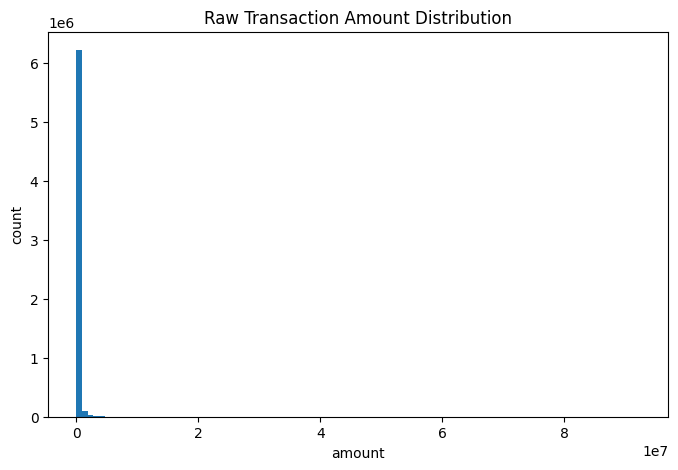

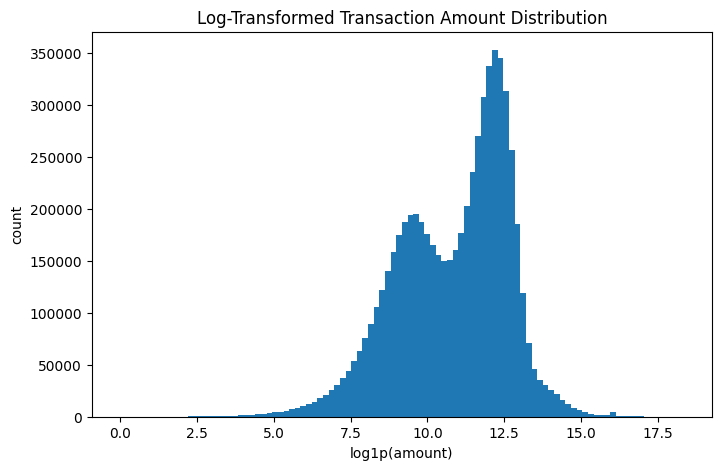

In [7]:
df['log_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(8, 5))
plt.hist(df['amount'], bins=100)
plt.title('Raw Transaction Amount Distribution')
plt.xlabel('amount')
plt.ylabel('count')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['log_amount'], bins=100)
plt.title('Log-Transformed Transaction Amount Distribution')
plt.xlabel('log1p(amount)')
plt.ylabel('count')
plt.show()

### Why `log_amount` is used

The raw transaction amount distribution is highly right-skewed, with a long upper tail driven by relatively few very large transactions. A log transformation compresses that tail while preserving the rank ordering of transaction size.

For that reason, `log_amount` will be used in the main models instead of raw `amount`. This is especially useful for logistic regression, where extreme values in the raw feature can dominate the fit.

### 1.6 Time structure

The variable `step` is an hourly time index, and the dataset spans roughly 30 days. This makes time an important part of the exploratory analysis.

This section reviews:
- the overall time range covered by the dataset,
- how transaction volume changes over time,
- and how fraud appears across the timeline.

Minimum step: 1
Maximum step: 743
Number of unique steps: 743


,isFraud,min,max,nunique
0,0,1,718,423
1,1,1,743,741


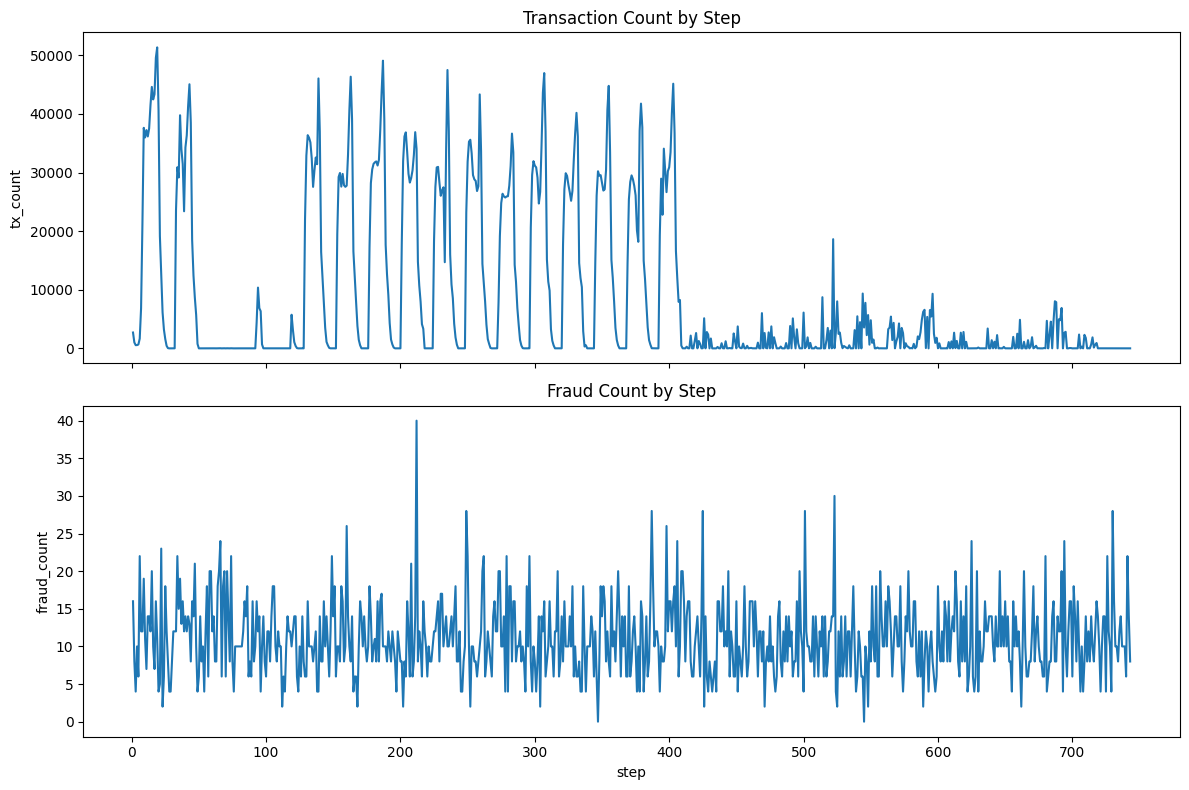

In [9]:
print("Minimum step:", df['step'].min())
print("Maximum step:", df['step'].max())
print("Number of unique steps:", df['step'].nunique())

time_summary = (
    df.groupby(TARGET)['step']
      .agg(['min', 'max', 'nunique'])
      .reset_index()
)

display(time_summary)

step_summary = (
    df.groupby('step')
      .agg(
          tx_count=(TARGET, 'size'),
          fraud_count=(TARGET, 'sum')
      )
      .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(step_summary['step'], step_summary['tx_count'])
axes[0].set_title('Transaction Count by Step')
axes[0].set_ylabel('tx_count')

axes[1].plot(step_summary['step'], step_summary['fraud_count'])
axes[1].set_title('Fraud Count by Step')
axes[1].set_xlabel('step')
axes[1].set_ylabel('fraud_count')

plt.tight_layout()
plt.show()

### Interpretation of the time structure

The temporal plots show that transaction volume changes substantially across the simulation timeline, while fraud remains present across much of the period rather than appearing only in one narrow window. This supports two modeling choices.

First, evaluation should be **time-based** rather than random, since the transaction environment changes over time. Second, `step` can be retained as a coarse temporal-position feature because it captures broad movement across the simulation timeline, while later features such as `hour_of_day` will capture within-day timing patterns.

### Final train / holdout split

The final split reserves the last 168 hours of data as the holdout period, corresponding to the final 7 days of simulated activity. This follows the case preference for a time-based holdout on the final portion of the timeline rather than a random split.

This design is more realistic for transaction monitoring because the model is trained on earlier transactions and then evaluated on later transactions, which better reflects how a production monitoring system would be used.

### 1.7 Identifier overlap and identity leakage review

The case explicitly warns against identity leakage across `nameOrig` and `nameDest`. Even with a time-based split, the same sender or receiver may still appear in both training and holdout periods.

This matters because raw identifiers can allow a model to memorize entities rather than learn generalizable suspicious-transaction behavior. The next step measures the overlap directly.

In [11]:
train_orig = set(train_df['nameOrig'].unique())
holdout_orig = set(holdout_df['nameOrig'].unique())

train_dest = set(train_df['nameDest'].unique())
holdout_dest = set(holdout_df['nameDest'].unique())

orig_overlap = train_orig & holdout_orig
dest_overlap = train_dest & holdout_dest

overlap_summary = pd.DataFrame([
    {
        'entity': 'nameOrig',
        'train_unique': f"{len(train_orig):,}",
        'holdout_unique': f"{len(holdout_orig):,}",
        'overlap_count': f"{len(orig_overlap):,}",
        'pct_holdout_seen_in_train': f"{len(orig_overlap) / len(holdout_orig):.4%}"
    },
    {
        'entity': 'nameDest',
        'train_unique': f"{len(train_dest):,}",
        'holdout_unique': f"{len(holdout_dest):,}",
        'overlap_count': f"{len(dest_overlap):,}",
        'pct_holdout_seen_in_train': f"{len(dest_overlap) / len(holdout_dest):.4%}"
    }
])

display(overlap_summary)

,entity,train_unique,holdout_unique,overlap_count,pct_holdout_seen_in_train
0,nameOrig,"6,191,455","162,300",448,0.2760%
1,nameDest,"2,650,236","153,466","81,340",53.0020%


### Interpretation of identifier overlap

The overlap analysis shows that raw sender and receiver identifiers could allow a model to memorize entities across time rather than learn generalizable suspicious-transaction behavior.

For that reason:
- `nameOrig` and `nameDest` will **not** be used directly as model inputs
- these fields will only be used to derive behavioral history features such as novelty indicators and prior activity counts

This preserves entity-level behavioral signal while reducing identity-based memorization risk.

### 1.8 Balance-column leakage note and core feature policy

The case notes that transactions detected or blocked by the simulator are cancelled, so the four balance columns can leak the label. For that reason, the following columns are excluded from the core supervised models:

- `oldbalanceOrg`
- `newbalanceOrig`
- `oldbalanceDest`
- `newbalanceDest`

The core feature policy used in this notebook is therefore:

- use `isFraud` as the target
- exclude the four balance columns from the main models
- exclude raw sender/receiver identifiers as direct model inputs
- construct only features based on information available up to the current transaction

### 1.9 Candidate feature construction

The next step is to construct a broader candidate feature pool than will ultimately be used in the first benchmark model.

The candidate pool includes:

- **Core transaction features**
  - `step`
  - `type`
  - `amount`
  - `log_amount`
  - `hour_of_day`

- **Behavioral novelty**
  - `orig_is_first_seen`
  - `dest_is_first_seen`

- **Entity-history activity**
  - prior transaction counts
  - prior total amounts
  - prior average amounts

- **Recent activity**
  - prior 24-hour transaction counts
  - prior 24-hour total amounts

The purpose of this section is to construct a broader pool first, then screen it before final model selection.

In [13]:
df = df_raw.copy()

if 'transaction_id' not in df.columns:
    df['transaction_id'] = df.index

if 'log_amount' not in df.columns:
    df['log_amount'] = np.log1p(df['amount'])

if 'hour_of_day' not in df.columns:
    df['hour_of_day'] = df['step'] % 24

df = df.sort_values(['step', 'transaction_id'], kind='mergesort').copy()


def add_candidate_entity_features(base_df, entity_col, prefix, window_hours=24):
    """
    Build a richer set of strictly prior-step-only entity-history features.

    Candidate features:
    - first-seen flag
    - prior transaction count
    - prior total amount
    - prior average amount
    - prior rolling-window transaction count
    - prior rolling-window total amount
    """
    step_agg = (
        base_df.groupby([entity_col, 'step'], as_index=False, observed=True)
        .agg(
            step_tx_count=('amount', 'size'),
            step_total_amount=('amount', 'sum')
        )
        .sort_values([entity_col, 'step'], kind='mergesort')
        .copy()
    )

    grp = step_agg.groupby(entity_col, observed=True, sort=False)

    step_agg[f'{prefix}_prior_tx_count'] = (
        grp['step_tx_count'].cumsum() - step_agg['step_tx_count']
    )

    step_agg[f'{prefix}_prior_total_amount'] = (
        grp['step_total_amount'].cumsum() - step_agg['step_total_amount']
    )

    step_agg[f'{prefix}_prior_avg_amount'] = np.where(
        step_agg[f'{prefix}_prior_tx_count'] > 0,
        step_agg[f'{prefix}_prior_total_amount'] / step_agg[f'{prefix}_prior_tx_count'],
        0.0
    )

    step_agg[f'{prefix}_is_first_seen'] = (
        step_agg[f'{prefix}_prior_tx_count'] == 0
    ).astype('int8')

    step_agg['step_time'] = pd.to_timedelta(step_agg['step'], unit='h')

    step_agg[f'{prefix}_prior_{window_hours}h_tx_count'] = (
        step_agg.groupby(entity_col, observed=True)
        .rolling(f'{window_hours}h', on='step_time', closed='left')['step_tx_count']
        .sum()
        .reset_index(level=0, drop=True)
        .fillna(0)
        .to_numpy()
    )

    step_agg[f'{prefix}_prior_{window_hours}h_total_amount'] = (
        step_agg.groupby(entity_col, observed=True)
        .rolling(f'{window_hours}h', on='step_time', closed='left')['step_total_amount']
        .sum()
        .reset_index(level=0, drop=True)
        .fillna(0)
        .to_numpy()
    )

    keep_cols = [
        entity_col,
        'step',
        f'{prefix}_is_first_seen',
        f'{prefix}_prior_tx_count',
        f'{prefix}_prior_total_amount',
        f'{prefix}_prior_avg_amount',
        f'{prefix}_prior_{window_hours}h_tx_count',
        f'{prefix}_prior_{window_hours}h_total_amount'
    ]

    step_agg = step_agg[keep_cols].set_index([entity_col, 'step'])

    overlap_cols = [c for c in step_agg.columns if c in base_df.columns]
    if overlap_cols:
        base_df = base_df.drop(columns=overlap_cols)

    base_df = base_df.join(step_agg, on=[entity_col, 'step'])
    return base_df


df = add_candidate_entity_features(df, 'nameOrig', 'orig', window_hours=24)
df = add_candidate_entity_features(df, 'nameDest', 'dest', window_hours=24)

candidate_numeric_history_cols = [
    'orig_prior_tx_count',
    'orig_prior_total_amount',
    'orig_prior_avg_amount',
    'orig_prior_24h_tx_count',
    'orig_prior_24h_total_amount',
    'dest_prior_tx_count',
    'dest_prior_total_amount',
    'dest_prior_avg_amount',
    'dest_prior_24h_tx_count',
    'dest_prior_24h_total_amount'
]

for col in candidate_numeric_history_cols:
    df[f'log_{col}'] = np.log1p(df[col])

train_df = df[df['step'] < holdout_start].copy()
holdout_df = df[df['step'] >= holdout_start].copy()

candidate_preview_cols = [
    'step', 'type', 'amount', 'log_amount', 'hour_of_day',
    'orig_is_first_seen', 'dest_is_first_seen',
    'orig_prior_tx_count', 'dest_prior_tx_count',
    'orig_prior_total_amount', 'dest_prior_total_amount',
    'orig_prior_avg_amount', 'dest_prior_avg_amount',
    'orig_prior_24h_tx_count', 'dest_prior_24h_tx_count'
]

display(df[candidate_preview_cols].head(10))

,step,type,amount,log_amount,hour_of_day,orig_is_first_seen,dest_is_first_seen,orig_prior_tx_count,dest_prior_tx_count,orig_prior_total_amount,dest_prior_total_amount,orig_prior_avg_amount,dest_prior_avg_amount,orig_prior_24h_tx_count,dest_prior_24h_tx_count
0,1,PAYMENT,"9,839.640000",9.194276,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,PAYMENT,"1,864.280000",7.531166,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,TRANSFER,181.000000,5.204007,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,CASH_OUT,181.000000,5.204007,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,PAYMENT,"11,668.140000",9.364703,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1,PAYMENT,"7,817.710000",8.964275,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,1,PAYMENT,"7,107.770000",8.869085,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,1,PAYMENT,"7,861.640000",8.969878,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,1,PAYMENT,"4,024.360000",8.300370,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,1,DEBIT,"5,337.770000",8.582751,1,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [70]:
display(df[candidate_preview_cols].tail(10))

,step,type,amount,log_amount,hour_of_day,orig_is_first_seen,dest_is_first_seen,orig_prior_tx_count,dest_prior_tx_count,orig_prior_total_amount,dest_prior_total_amount,orig_prior_avg_amount,dest_prior_avg_amount,orig_prior_24h_tx_count,dest_prior_24h_tx_count
6362610,742,TRANSFER,"63,416.990000",11.057503,22,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6362611,742,CASH_OUT,"63,416.990000",11.057503,22,1,0,0,3,0.000000,"438,545.230000",0.000000,"146,181.743333",0.000000,0.000000
6362612,743,TRANSFER,"1,258,818.820000",14.045685,23,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6362613,743,CASH_OUT,"1,258,818.820000",14.045685,23,1,0,0,5,0.000000,"1,404,436.370000",0.000000,"280,887.274000",0.000000,0.000000
6362614,743,TRANSFER,"339,682.130000",12.735768,23,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6362615,743,CASH_OUT,"339,682.130000",12.735768,23,1,0,0,1,0.000000,"325,100.590000",0.000000,"325,100.590000",0.000000,0.000000
6362616,743,TRANSFER,"6,311,409.280000",15.657870,23,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6362617,743,CASH_OUT,"6,311,409.280000",15.657870,23,1,0,0,2,0.000000,"326,003.640000",0.000000,"163,001.820000",0.000000,0.000000
6362618,743,TRANSFER,"850,002.520000",13.652996,23,1,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6362619,743,CASH_OUT,"850,002.520000",13.652996,23,1,0,0,27,0.000000,"8,100,215.140000",0.000000,"300,007.968148",0.000000,0.000000


### 1.10 Candidate feature screening

Now that a broader candidate feature pool has been created, the next step is to screen these features before model building.

The purpose of screening is not to make final feature-selection decisions from univariate summaries alone. Instead, it is to answer a few practical questions:

- Which features show meaningful separation between fraud and non-fraud?
- Which features are highly skewed and benefit from transformation?
- Which features appear redundant with one another?
- Which features are promising enough to carry forward into the benchmark models?

The screening process will use:
- summary statistics by fraud label
- visual inspection of selected feature behavior
- correlation analysis for numeric candidate features

amount                log_amount                 step  \
                    mean         median       mean    median       mean   
isFraud                                                                   
0         178,197.041727  74,684.720000  10.838223 11.221044 243.235663   
1       1,467,967.299140 441,423.440000  12.892027 12.997762 368.413856   

                   hour_of_day           orig_is_first_seen           \
            median        mean    median               mean   median   
isFraud                                                                
0       239.000000   15.326333 16.000000           0.998545 1.000000   
1       367.000000   11.546451 12.000000           0.997808 1.000000   

        dest_is_first_seen          orig_prior_tx_count           \
                      mean   median                mean   median   
isFraud                                                            
0                 0.435085 0.000000            0.001458 0.000000   
1                 0.632656 1.000000            0.002192 0.000000   

        dest_prior_tx_count          orig_prior_total_amount           \
                       mean   median                    mean   median   
isFraud                                                                 
0                  5.030144 1.000000              259.433870 0.000000   
1                  2.687690 0.000000              288.607282 0.000000   

        dest_prior_total_amount                orig_prior_avg_amount           \
                           mean         median                  mean   median   
isFraud                                                                         
0              1,334,175.932058 207,513.370000            259.118924 0.000000   
1                703,473.087987       0.000000            288.607282 0.000000   

        dest_prior_avg_amount               orig_prior_24h_tx_count           \
                         mean        median                    mean   median   
isFraud                                                                        
0              141,238.090591 99,263.160000                0.000174 0.000000   
1               82,286.111857      0.000000                0.000244 0.000000   

        dest_prior_24h_tx_count          orig_prior_24h_total_amount           \
                           mean   median                        mean   median   
isFraud                                                                         
0                      1.062490 0.000000                   40.918280 0.000000   
1                      0.324120 0.000000                   10.222018 0.000000   

        dest_prior_24h_total_amount          log_orig_prior_tx_count           \
                               mean   median                    mean   median   
isFraud                                                                         
0                    300,243.567777 0.000000                0.001010 0.000000   
1                     80,841.573910 0.000000                0.001519 0.000000   

        log_dest_prior_tx_count          log_orig_prior_total_amount           \
                           mean   median                        mean   median   
isFraud                                                                         
0                      1.108884 0.693147                    0.015728 0.000000   
1                      0.648649 0.000000                    0.023827 0.000000   

        log_dest_prior_total_amount           log_orig_prior_avg_amount  \
                               mean    median                      mean   
isFraud                                                                   
0                          7.851455 12.242956                  0.015726   
1                          4.959214  0.000000                  0.023827   

                 log_dest_prior_avg_amount            \
          median                      mean    median   
isFraud                                                
0    

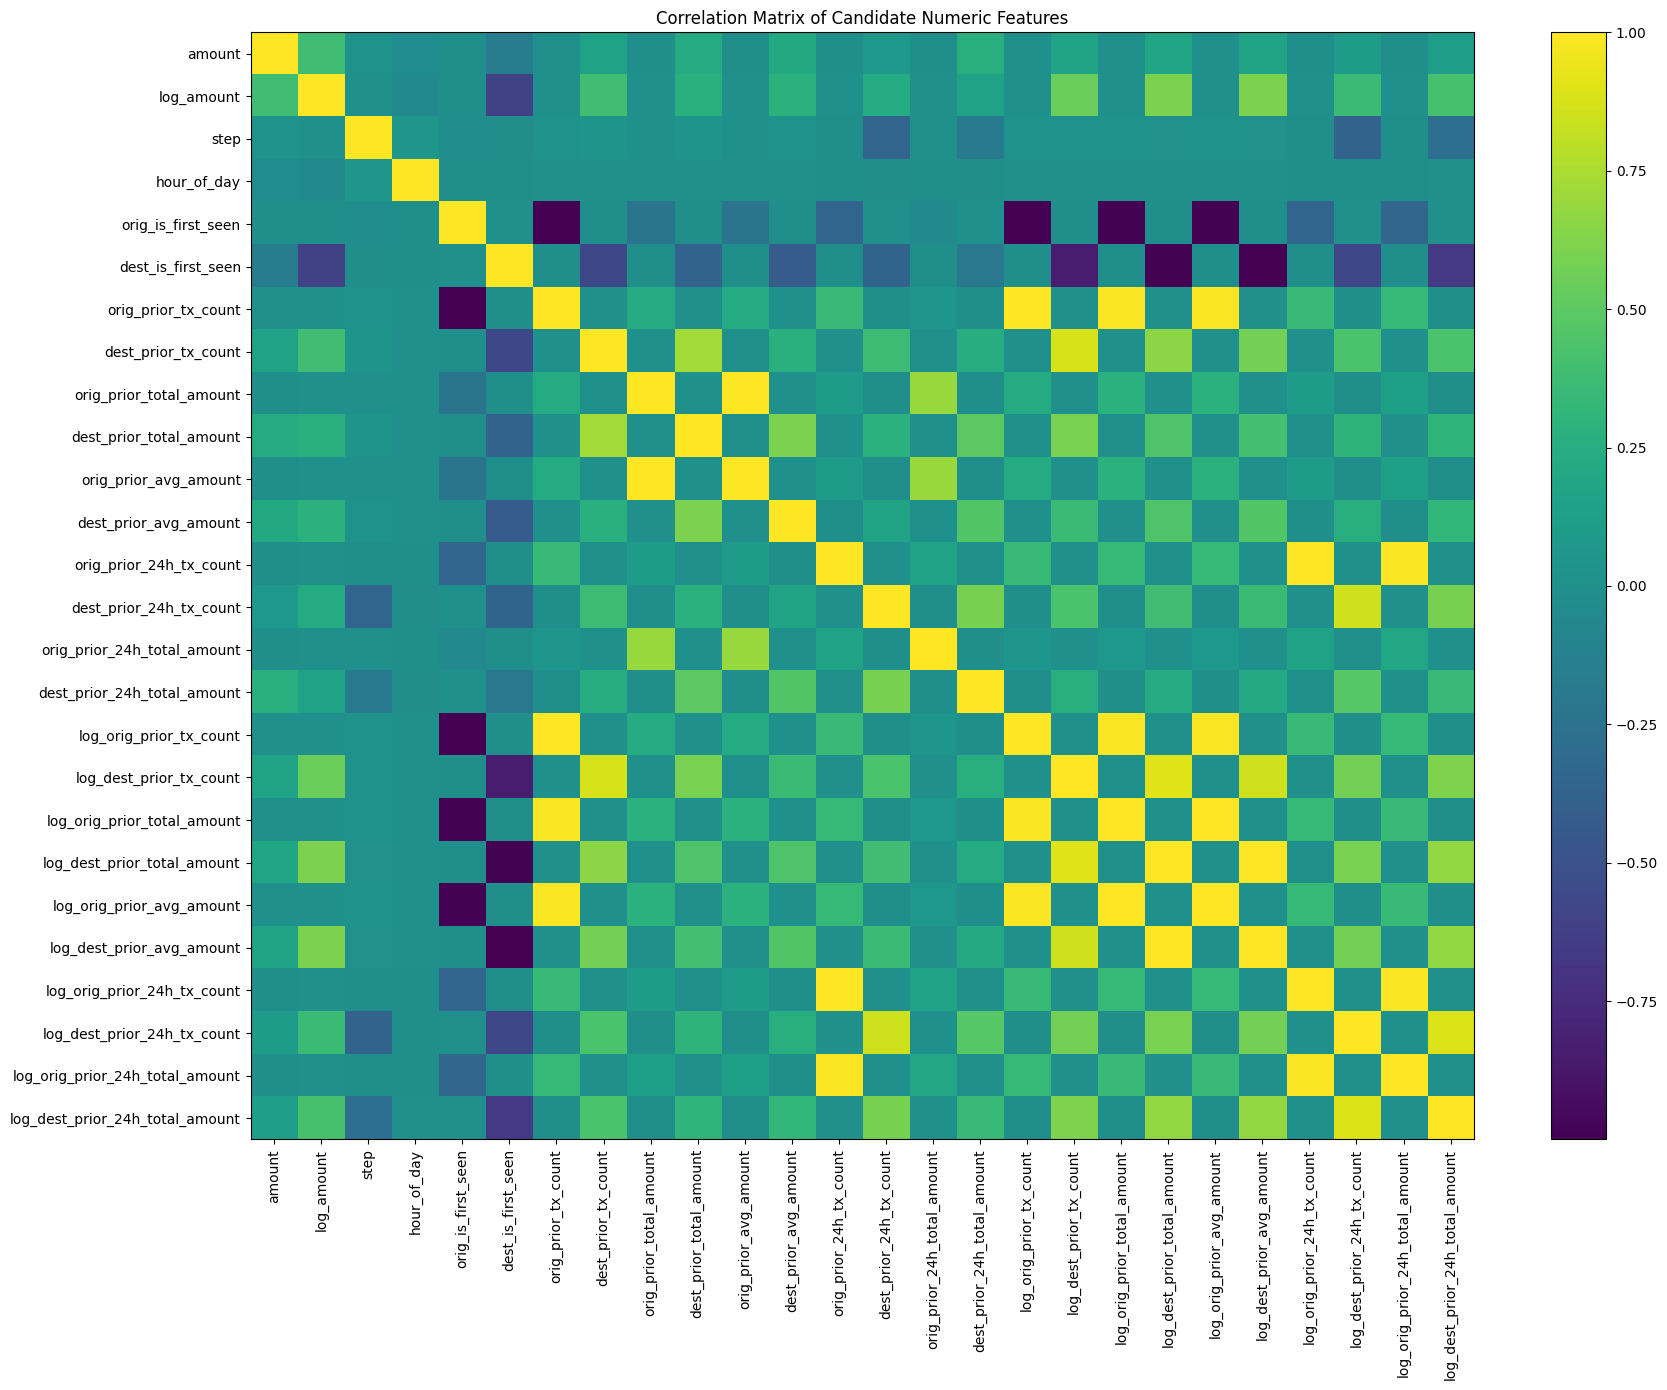

In [16]:
candidate_numeric_features = [
    'amount',
    'log_amount',
    'step',
    'hour_of_day',
    'orig_is_first_seen',
    'dest_is_first_seen',
    'orig_prior_tx_count',
    'dest_prior_tx_count',
    'orig_prior_total_amount',
    'dest_prior_total_amount',
    'orig_prior_avg_amount',
    'dest_prior_avg_amount',
    'orig_prior_24h_tx_count',
    'dest_prior_24h_tx_count',
    'orig_prior_24h_total_amount',
    'dest_prior_24h_total_amount',
    'log_orig_prior_tx_count',
    'log_dest_prior_tx_count',
    'log_orig_prior_total_amount',
    'log_dest_prior_total_amount',
    'log_orig_prior_avg_amount',
    'log_dest_prior_avg_amount',
    'log_orig_prior_24h_tx_count',
    'log_dest_prior_24h_tx_count',
    'log_orig_prior_24h_total_amount',
    'log_dest_prior_24h_total_amount'
]

feature_screening_summary = (
    df.groupby(TARGET)[candidate_numeric_features]
      .agg(['mean', 'median'])
)

display(feature_screening_summary)

# Correlation matrix for numeric candidate features
corr_df = df[candidate_numeric_features].corr()

plt.figure(figsize=(18, 14))
plt.imshow(corr_df, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title('Correlation Matrix of Candidate Numeric Features')
plt.tight_layout()
plt.show()

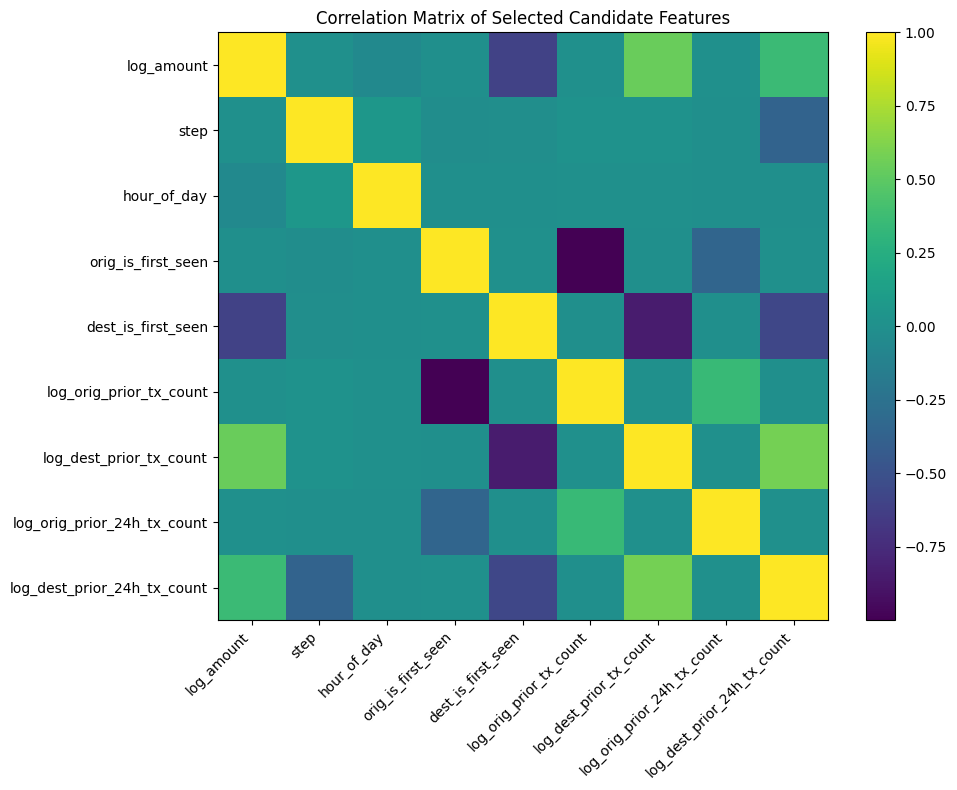

In [17]:
selected_corr_features = [
    'log_amount',
    'step',
    'hour_of_day',
    'orig_is_first_seen',
    'dest_is_first_seen',
    'log_orig_prior_tx_count',
    'log_dest_prior_tx_count',
    'log_orig_prior_24h_tx_count',
    'log_dest_prior_24h_tx_count'
]

corr_df_selected = df[selected_corr_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df_selected, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(corr_df_selected.columns)),
    corr_df_selected.columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(corr_df_selected.index)),
    corr_df_selected.index
)

plt.title('Correlation Matrix of Selected Candidate Features')
plt.tight_layout()
plt.show()

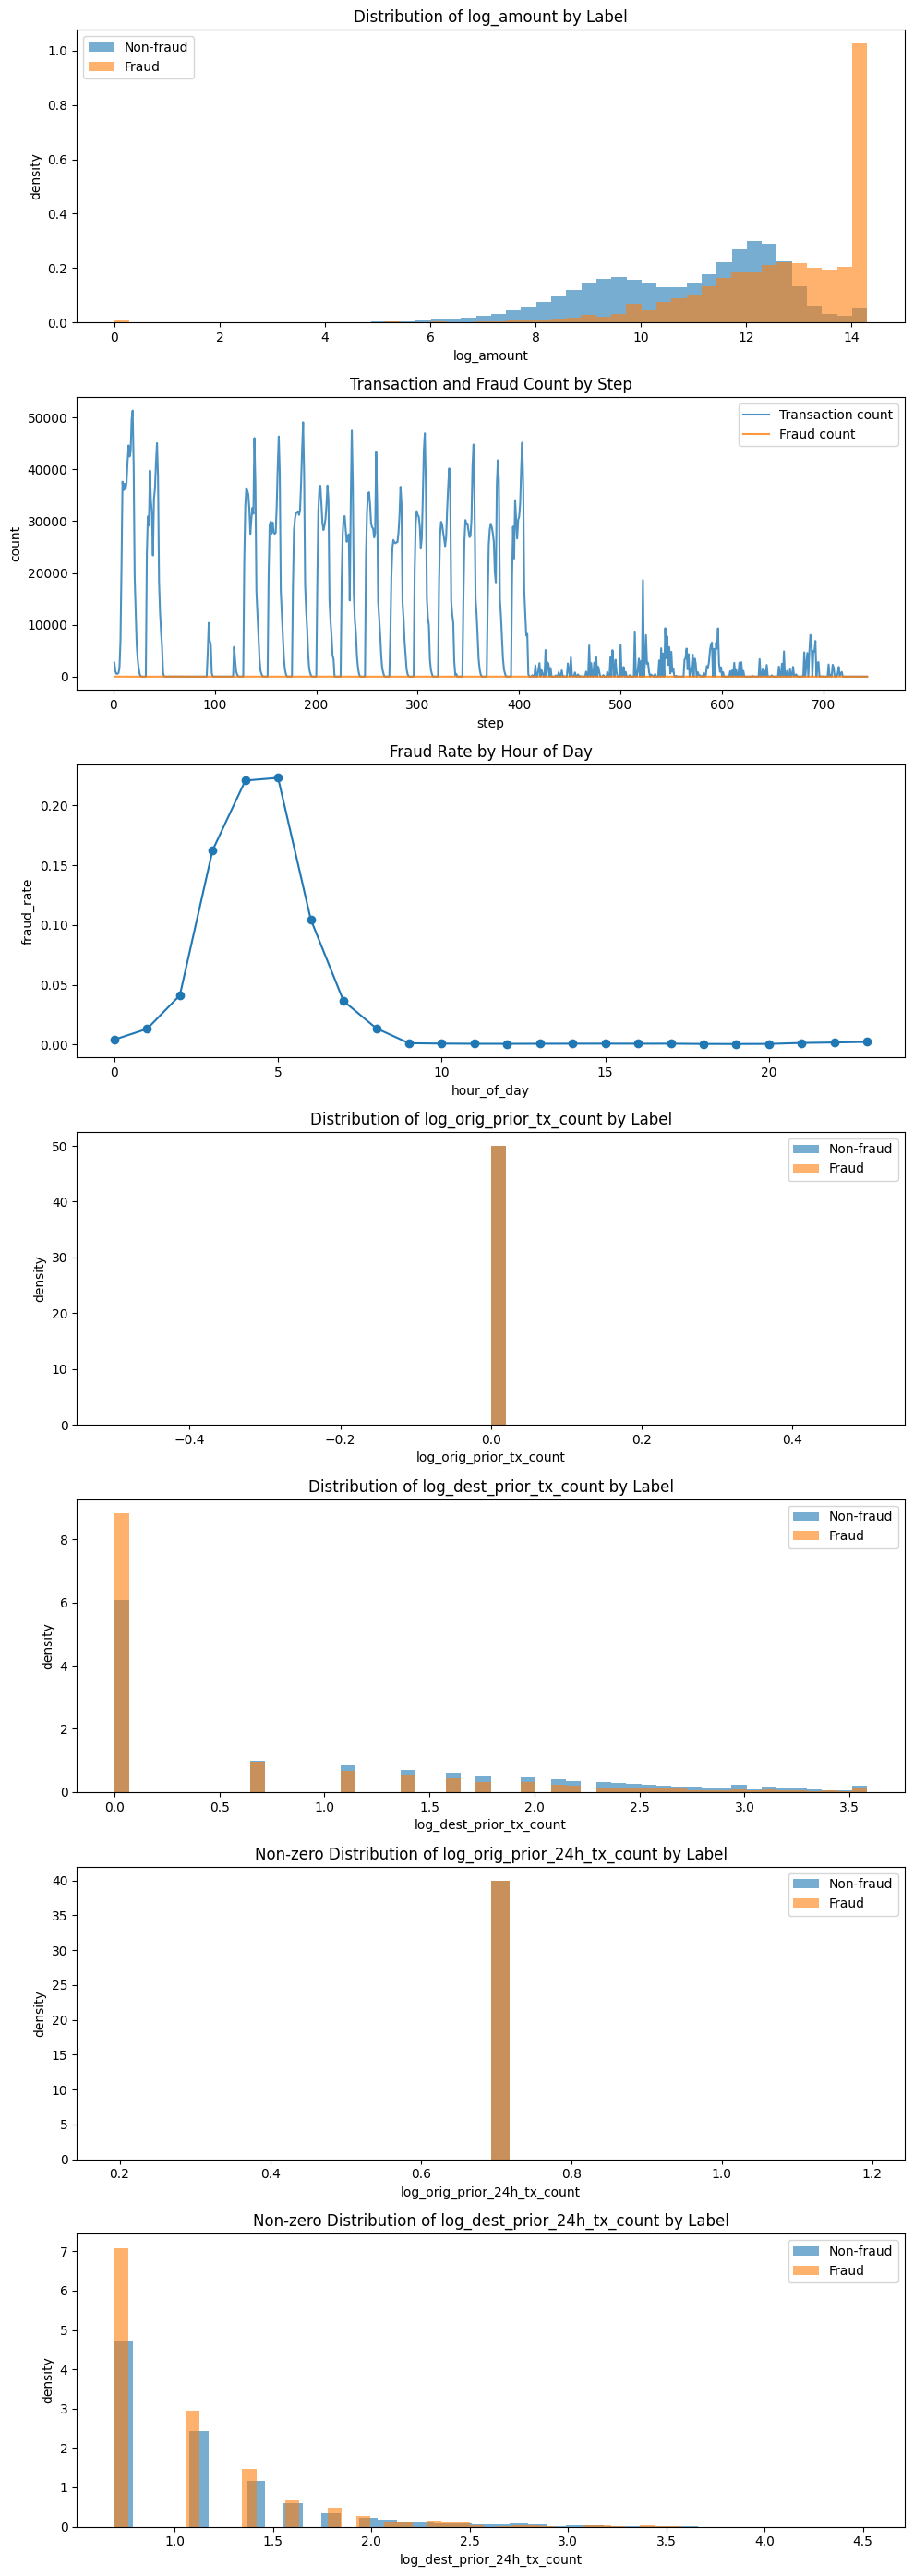

In [18]:
# Visual screening of selected candidate features by fraud label
selected_plot_features = [
    'log_amount',
    'step',
    'hour_of_day',
    'log_orig_prior_tx_count',
    'log_dest_prior_tx_count',
    'log_orig_prior_24h_tx_count',
    'log_dest_prior_24h_tx_count'
]

fig, axes = plt.subplots(len(selected_plot_features), 1, figsize=(10, 4 * len(selected_plot_features)))

if len(selected_plot_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, selected_plot_features):
    
    # 1) step: use count plots instead of density histogram
    if feature == 'step':
        step_plot_df = (
            df.groupby('step')
              .agg(
                  tx_count=(TARGET, 'size'),
                  fraud_count=(TARGET, 'sum')
              )
              .reset_index()
        )

        ax.plot(step_plot_df['step'], step_plot_df['tx_count'], label='Transaction count', alpha=0.8)
        ax.plot(step_plot_df['step'], step_plot_df['fraud_count'], label='Fraud count', alpha=0.8)
        ax.set_title('Transaction and Fraud Count by Step')
        ax.set_xlabel('step')
        ax.set_ylabel('count')
        ax.legend()

    # 2) hour_of_day: use fraud rate by hour
    elif feature == 'hour_of_day':
        hour_plot_df = (
            df.groupby('hour_of_day')
              .agg(
                  tx_count=(TARGET, 'size'),
                  fraud_count=(TARGET, 'sum')
              )
              .reset_index()
        )
        hour_plot_df['fraud_rate'] = hour_plot_df['fraud_count'] / hour_plot_df['tx_count']

        ax.plot(hour_plot_df['hour_of_day'], hour_plot_df['fraud_rate'], marker='o')
        ax.set_title('Fraud Rate by Hour of Day')
        ax.set_xlabel('hour_of_day')
        ax.set_ylabel('fraud_rate')

    # 3) zero-inflated recent-count features: show only non-zero tail
    elif feature in ['log_orig_prior_24h_tx_count', 'log_dest_prior_24h_tx_count']:
        fraud_values = df.loc[(df[TARGET] == 1) & (df[feature] > 0), feature]
        nonfraud_values = df.loc[(df[TARGET] == 0) & (df[feature] > 0), feature]

        if len(fraud_values) == 0 and len(nonfraud_values) == 0:
            ax.text(0.5, 0.5, f'All values are zero for {feature}', ha='center', va='center')
            ax.set_axis_off()
        else:
            ax.hist(nonfraud_values, bins=40, alpha=0.6, density=True, label='Non-fraud')
            ax.hist(fraud_values, bins=40, alpha=0.6, density=True, label='Fraud')
            ax.set_title(f'Non-zero Distribution of {feature} by Label')
            ax.set_xlabel(feature)
            ax.set_ylabel('density')
            ax.legend()

    # 4) other continuous features: use the original overlay histogram
    else:
        fraud_values = df.loc[df[TARGET] == 1, feature]
        nonfraud_values = df.loc[df[TARGET] == 0, feature]

        upper = df[feature].quantile(0.99)
        fraud_values = fraud_values.clip(upper=upper)
        nonfraud_values = nonfraud_values.clip(upper=upper)

        ax.hist(nonfraud_values, bins=50, alpha=0.6, density=True, label='Non-fraud')
        ax.hist(fraud_values, bins=50, alpha=0.6, density=True, label='Fraud')
        ax.set_title(f'Distribution of {feature} by Label')
        ax.set_xlabel(feature)
        ax.set_ylabel('density')
        ax.legend()

plt.tight_layout()
plt.show()

### Visual screening of selected candidate features

The selected candidate features are not all visualized in the same way because they have different statistical structures.

- Continuous transformed variables are reviewed with overlaid label distributions.
- `step` is reviewed with transaction and fraud count plots rather than a density histogram.
- `hour_of_day` is reviewed with fraud rate by hour.
- Recent 24-hour count features are highly sparse, so they are reviewed using non-zero tail distributions.

This keeps the screening plots more interpretable and avoids misleading visualizations for discrete or zero-inflated features.

### 1.11 Features selected for modeling

Based on the screening results, the main modeling workflow will carry forward a smaller subset of features that balances:

- predictive plausibility,
- interpretability,
- manageable redundancy,
- and computational practicality.

The selected modeling features are:

- **Core transaction features**
  - `step`
  - `type`
  - `log_amount`

- **Temporal refinement**
  - `hour_of_day`

- **Behavioral novelty**
  - `orig_is_first_seen`
  - `dest_is_first_seen`

- **Entity-history activity**
  - `log_orig_prior_tx_count`
  - `log_dest_prior_tx_count`

- **Recent activity**
  - `log_orig_prior_24h_tx_count`
  - `log_dest_prior_24h_tx_count`

Not all of these features will necessarily remain in the final benchmark. The next section will use controlled model comparisons to determine which blocks provide meaningful incremental value.

## Section 2. Logistic-regression benchmark

This section develops the logistic-regression benchmark used throughout the case study.

The workflow is:

1. define the baseline model,
2. define the candidate feature blocks,
3. create the train / validation / holdout split,
4. compare logistic candidates on validation,
5. select the best logistic model and threshold,
6. retrain on train + validation and evaluate once on holdout.

### 2.1 Baseline model: logistic regression

The first benchmark model uses a compact transaction-level feature set:

- `step`
- `type`
- `log_amount`

This specification is intentionally simple. It captures:
- broad temporal position in the simulation timeline,
- transaction-category information,
- and transaction size in a more stable transformed form.

A logistic-regression baseline is useful because it is interpretable, reproducible, and easy to justify in a model-governance setting.

### 2.2 Candidate feature blocks for logistic regression

After establishing the baseline, the next step is to define a small set of candidate feature blocks for the logistic-regression benchmark.

The candidate blocks are:

- **Temporal refinement**
  - `hour_of_day`

- **Behavioral novelty**
  - `orig_is_first_seen`
  - `dest_is_first_seen`

- **Entity-history activity**
  - `log_orig_prior_tx_count`
  - `log_dest_prior_tx_count`

- **Recent activity**
  - `log_orig_prior_24h_tx_count`
  - `log_dest_prior_24h_tx_count`

These blocks are proposed as structured additions to the baseline model. The goal is to test whether they provide meaningful lift while keeping the logistic benchmark compact and interpretable.

### 2.3 Train / validation / holdout setup

Model selection and threshold selection should not use the holdout set.

From this point onward, the dataset is split into three parts:

- **train**: used to fit candidate models
- **validation**: used to compare candidate models and choose thresholds
- **holdout**: reserved for final one-time reporting only

This keeps model comparison, threshold selection, and final evaluation separated cleanly.

In [25]:
# Final 7 days remain the holdout set
step_max = int(df['step'].max())
holdout_start = step_max - HOLDOUT_HOURS + 1

train_valid_df = df[df['step'] < holdout_start].copy()
holdout_df = df[df['step'] >= holdout_start].copy()

# Within the pre-holdout period, reserve the last 4 days as validation
valid_start = int(train_valid_df['step'].max()) - INNER_VALID_HOURS + 1

train_df = train_valid_df[train_valid_df['step'] < valid_start].copy()
valid_df = train_valid_df[train_valid_df['step'] >= valid_start].copy()

split_summary = pd.DataFrame([
    {
        'dataset': 'train',
        'step_range': f"{train_df['step'].min()} - {train_df['step'].max()}",
        'rows': f"{len(train_df):,}",
        'fraud_count': f"{int(train_df[TARGET].sum()):,}"
    },
    {
        'dataset': 'validation',
        'step_range': f"{valid_df['step'].min()} - {valid_df['step'].max()}",
        'rows': f"{len(valid_df):,}",
        'fraud_count': f"{int(valid_df[TARGET].sum()):,}"
    },
    {
        'dataset': 'holdout',
        'step_range': f"{holdout_df['step'].min()} - {holdout_df['step'].max()}",
        'rows': f"{len(holdout_df):,}",
        'fraud_count': f"{int(holdout_df[TARGET].sum()):,}"
    }
])

display(split_summary)

,dataset,step_range,rows,fraud_count
0,train,1 - 479,"6,039,437","5,343"
1,validation,480 - 575,"160,880","1,016"
2,holdout,576 - 743,"162,303","1,854"


### 2.4 Baseline logistic model on train / validation

In [26]:
baseline_features = ['step', 'type', 'log_amount']

X_train_base = train_df[baseline_features].copy()
y_train_base = train_df[TARGET].copy()

X_valid_base = valid_df[baseline_features].copy()
y_valid_base = valid_df[TARGET].copy()

numeric_features_base = ['step', 'log_amount']
categorical_features_base = ['type']

numeric_transformer_base = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_base = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_base = ColumnTransformer(transformers=[
    ('num', numeric_transformer_base, numeric_features_base),
    ('cat', categorical_transformer_base, categorical_features_base)
])

log_reg_pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED
    ))
])

log_reg_pipeline_base.fit(X_train_base, y_train_base)
valid_scores_base = log_reg_pipeline_base.predict_proba(X_valid_base)[:, 1]

baseline_roc_auc = roc_auc_score(y_valid_base, valid_scores_base)
baseline_pr_auc = average_precision_score(y_valid_base, valid_scores_base)

baseline_metric_summary = pd.DataFrame([
    {'metric': 'Validation ROC AUC', 'value': baseline_roc_auc},
    {'metric': 'Validation PR AUC', 'value': baseline_pr_auc}
])

display(baseline_metric_summary)

,metric,value
0,Validation ROC AUC,0.890698
1,Validation PR AUC,0.061089


### 2.4 Logistic candidate comparison on validation

In [27]:
baseline_core = ['step', 'type', 'log_amount']

feature_blocks = {
    'temporal': ['hour_of_day'],
    'novelty': ['orig_is_first_seen', 'dest_is_first_seen'],
    'prior_count': ['log_orig_prior_tx_count', 'log_dest_prior_tx_count'],
    'recent_count_24h': ['log_orig_prior_24h_tx_count', 'log_dest_prior_24h_tx_count']
}

categorical_candidates = {'type', 'hour_of_day'}

def run_logreg_spec(train_data, test_data, feature_list, model_name):
    numeric_features = [c for c in feature_list if c not in categorical_candidates]
    categorical_features = [c for c in feature_list if c in categorical_candidates]

    X_train = train_data[feature_list].copy()
    y_train = train_data[TARGET].copy()

    X_test = test_data[feature_list].copy()
    y_test = test_data[TARGET].copy()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=SEED
        ))
    ])

    pipeline.fit(X_train, y_train)
    test_scores = pipeline.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, test_scores)
    pr_auc = average_precision_score(y_test, test_scores)

    return {
        'model_name': model_name,
        'feature_count': len(feature_list),
        'features': feature_list,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'pipeline': pipeline,
        'scores': test_scores
    }

block_names = list(feature_blocks.keys())
logit_selection_results = []

for r in range(len(block_names) + 1):
    for combo in combinations(block_names, r):
        selected_features = baseline_core.copy()
        for block in combo:
            selected_features += feature_blocks[block]

        model_name = 'Baseline' if len(combo) == 0 else 'Baseline + ' + ' + '.join(combo)

        result = run_logreg_spec(
            train_data=train_df,
            test_data=valid_df,
            feature_list=selected_features,
            model_name=model_name
        )
        logit_selection_results.append(result)

logit_selection_df = pd.DataFrame([
    {
        'model_name': r['model_name'],
        'feature_count': r['feature_count'],
        'roc_auc': r['roc_auc'],
        'pr_auc': r['pr_auc']
    }
    for r in logit_selection_results
]).sort_values(['pr_auc', 'roc_auc'], ascending=[False, False]).reset_index(drop=True)

display(logit_selection_df)

,model_name,feature_count,roc_auc,pr_auc
0,Baseline + temporal + novelty + prior_count,8,0.947863,0.326763
1,Baseline + temporal + novelty + prior_count + ...,10,0.947734,0.326630
2,Baseline + temporal + novelty,6,0.946352,0.324822
3,Baseline + temporal + novelty + recent_count_24h,8,0.946317,0.320201
4,Baseline + temporal + prior_count,6,0.945021,0.316626
5,Baseline + temporal + prior_count + recent_cou...,8,0.944916,0.304020
6,Baseline + temporal + recent_count_24h,6,0.926792,0.199046
7,Baseline + temporal,4,0.926051,0.196103
8,Baseline + novelty + prior_count + recent_coun...,9,0.925668,0.185794
9,Baseline + novelty + prior_count,7,0.924869,0.184789


### Interpretation of the logistic-regression comparison

The logistic-regression candidates are compared on the validation set rather than on the holdout set. This keeps the final holdout period reserved for one-time reporting only.

The comparison is based primarily on **PR AUC**, because the fraud label is extremely imbalanced and the practical objective is to push suspicious transactions toward the top of the score ranking. **ROC AUC** remains useful as a secondary ranking metric.

This comparison is intended to answer two questions:

1. Which feature blocks add meaningful incremental value beyond the baseline?
2. At what point does additional feature complexity stop producing meaningful lift?

In [28]:
def evaluate_thresholds(y_true, scores, fn_cost=FN_COST, fp_cost=FP_COST, n_thresholds=50):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    rows = []

    for thr in thresholds:
        preds = (scores >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)
        f2 = fbeta_score(y_true, preds, beta=2, zero_division=0)

        alert_volume = int(tp + fp)
        alert_rate = preds.mean()
        expected_cost = fn_cost * fn + fp_cost * fp

        rows.append({
            'threshold': thr,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'f2': f2,
            'alert_volume': alert_volume,
            'alert_rate': alert_rate,
            'expected_cost': expected_cost
        })

    return pd.DataFrame(rows)

### 2.5 Best logistic model and threshold selection

After the validation comparison is complete, the strongest logistic-regression specification will be selected using validation PR AUC, with validation ROC AUC used as a secondary ranking metric.

Once the best specification is identified, its decision threshold will also be selected on the validation set. The threshold review will include:

- precision
- recall
- F1
- F2
- alert volume
- alert rate
- expected cost

After both the model and threshold are fixed, the selected logistic model will be retrained on **train + validation**, and the locked threshold will then be applied once to the holdout set for final reporting.

In [29]:
best_logit_result = max(logit_selection_results, key=lambda x: (x['pr_auc'], x['roc_auc']))

best_logit_model_name = best_logit_result['model_name']
best_logit_features = best_logit_result['features']
best_logit_valid_scores = best_logit_result['scores']

best_logit_selection_summary = pd.DataFrame([
    {'metric': 'Selected logistic model', 'value': best_logit_model_name},
    {'metric': 'Number of features', 'value': len(best_logit_features)},
    {'metric': 'Validation ROC AUC', 'value': best_logit_result['roc_auc']},
    {'metric': 'Validation PR AUC', 'value': best_logit_result['pr_auc']}
])

display(best_logit_selection_summary)
print("Selected feature set:", best_logit_features)

,metric,value
0,Selected logistic model,Baseline + temporal + novelty + prior_count
1,Number of features,8
2,Validation ROC AUC,0.947863
3,Validation PR AUC,0.326763


Selected feature set: ['step', 'type', 'log_amount', 'hour_of_day', 'orig_is_first_seen', 'dest_is_first_seen', 'log_orig_prior_tx_count', 'log_dest_prior_tx_count']


#### Select the logistic threshold on validation

In [30]:
y_valid_logit = valid_df[TARGET].copy()

logit_valid_threshold_df = evaluate_thresholds(
    y_true=y_valid_logit,
    scores=best_logit_valid_scores,
    fn_cost=FN_COST,
    fp_cost=FP_COST,
    n_thresholds=50
)

print("Best logistic thresholds by expected cost on validation:")
display(logit_valid_threshold_df.sort_values('expected_cost').head(10))

print("Best logistic thresholds by F1 on validation:")
display(logit_valid_threshold_df.sort_values('f1', ascending=False).head(10))

print("Best logistic thresholds by F2 on validation:")
display(logit_valid_threshold_df.sort_values('f2', ascending=False).head(10))

chosen_threshold_logit = logit_valid_threshold_df.sort_values('expected_cost').iloc[0]['threshold']
print("Chosen logistic threshold from validation:", chosen_threshold_logit)

Best logistic thresholds by expected cost on validation:


,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost
29,0.590000,857,16158,159,143706,0.050367,0.843504,0.095059,0.203283,17015,0.105762,160290
27,0.550000,877,18304,139,141560,0.045722,0.863189,0.086845,0.188643,19181,0.119226,161020
28,0.570000,865,17114,151,142750,0.048112,0.851378,0.091077,0.196207,17979,0.111754,161070
30,0.610000,843,15358,173,144506,0.052034,0.829724,0.097926,0.207994,16201,0.100702,163290
31,0.630000,835,14611,181,145253,0.054059,0.821850,0.101446,0.213993,15446,0.096009,163555
26,0.530000,886,19733,130,140131,0.042970,0.872047,0.081904,0.179476,20619,0.128164,163665
32,0.650000,825,13950,191,145914,0.055838,0.812008,0.104490,0.218961,14775,0.091839,165250
25,0.510000,895,21381,121,138483,0.040178,0.880906,0.076850,0.169894,22276,0.138463,167405
34,0.690000,802,12702,214,147162,0.059390,0.789370,0.110468,0.228256,13504,0.083938,170510
33,0.670000,807,13302,209,146562,0.057198,0.794291,0.106711,0.222033,14109,0.087699,171010


Best logistic thresholds by F1 on validation:


,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost
47,0.950000,428,1050,588,158814,0.289581,0.421260,0.343224,0.386142,1478,0.009187,299250
48,0.970000,364,746,652,159118,0.327928,0.358268,0.342427,0.351759,1110,0.006900,329730
46,0.930000,498,1517,518,158347,0.247146,0.490157,0.328604,0.409607,2015,0.012525,266585
49,0.990000,290,537,726,159327,0.350665,0.285433,0.314704,0.296463,827,0.005140,365685
45,0.910000,567,2181,449,157683,0.206332,0.558071,0.301275,0.416177,2748,0.017081,235405
44,0.890000,609,2960,407,156904,0.170636,0.599409,0.265649,0.398926,3569,0.022184,218300
43,0.870000,650,4302,366,155562,0.131260,0.639764,0.217828,0.360470,4952,0.030781,204510
42,0.850000,685,5873,331,153991,0.104453,0.674213,0.180882,0.322444,6558,0.040763,194865
41,0.830000,712,7259,304,152605,0.089324,0.700787,0.158451,0.295804,7971,0.049546,188295
40,0.810000,725,8455,291,151409,0.078976,0.713583,0.142213,0.273709,9180,0.057061,187775


Best logistic thresholds by F2 on validation:


,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost
45,0.910000,567,2181,449,157683,0.206332,0.558071,0.301275,0.416177,2748,0.017081,235405
46,0.930000,498,1517,518,158347,0.247146,0.490157,0.328604,0.409607,2015,0.012525,266585
44,0.890000,609,2960,407,156904,0.170636,0.599409,0.265649,0.398926,3569,0.022184,218300
47,0.950000,428,1050,588,158814,0.289581,0.421260,0.343224,0.386142,1478,0.009187,299250
43,0.870000,650,4302,366,155562,0.131260,0.639764,0.217828,0.360470,4952,0.030781,204510
48,0.970000,364,746,652,159118,0.327928,0.358268,0.342427,0.351759,1110,0.006900,329730
42,0.850000,685,5873,331,153991,0.104453,0.674213,0.180882,0.322444,6558,0.040763,194865
49,0.990000,290,537,726,159327,0.350665,0.285433,0.314704,0.296463,827,0.005140,365685
41,0.830000,712,7259,304,152605,0.089324,0.700787,0.158451,0.295804,7971,0.049546,188295
40,0.810000,725,8455,291,151409,0.078976,0.713583,0.142213,0.273709,9180,0.057061,187775


Chosen logistic threshold from validation: 0.59


#### Retrain the best logistic model on train + validation

In [31]:
X_trainvalid_logit = train_valid_df[best_logit_features].copy()
y_trainvalid_logit = train_valid_df[TARGET].copy()

X_holdout_logit = holdout_df[best_logit_features].copy()
y_holdout_logit = holdout_df[TARGET].copy()

numeric_features_logit = [c for c in best_logit_features if c not in categorical_candidates]
categorical_features_logit = [c for c in best_logit_features if c in categorical_candidates]

numeric_transformer_logit = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_logit = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_logit = ColumnTransformer(transformers=[
    ('num', numeric_transformer_logit, numeric_features_logit),
    ('cat', categorical_transformer_logit, categorical_features_logit)
])

final_logit_model = Pipeline(steps=[
    ('preprocessor', preprocessor_logit),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED
    ))
])

final_logit_model.fit(X_trainvalid_logit, y_trainvalid_logit)
holdout_scores_logit = final_logit_model.predict_proba(X_holdout_logit)[:, 1]
holdout_preds_logit = (holdout_scores_logit >= chosen_threshold_logit).astype(int)

#### Final logistic-regression holdout report

In [32]:
best_logit_holdout_roc_auc = roc_auc_score(y_holdout_logit, holdout_scores_logit)
best_logit_holdout_pr_auc = average_precision_score(y_holdout_logit, holdout_scores_logit)

tn, fp, fn, tp = confusion_matrix(y_holdout_logit, holdout_preds_logit).ravel()

logit_holdout_final_summary = pd.DataFrame([
    {'metric': 'Selected logistic model', 'value': best_logit_model_name},
    {'metric': 'Chosen threshold (from validation)', 'value': chosen_threshold_logit},
    {'metric': 'Holdout ROC AUC', 'value': best_logit_holdout_roc_auc},
    {'metric': 'Holdout PR AUC', 'value': best_logit_holdout_pr_auc},
    {'metric': 'TP', 'value': tp},
    {'metric': 'FP', 'value': fp},
    {'metric': 'FN', 'value': fn},
    {'metric': 'TN', 'value': tn},
    {'metric': 'Precision', 'value': precision_score(y_holdout_logit, holdout_preds_logit, zero_division=0)},
    {'metric': 'Recall', 'value': recall_score(y_holdout_logit, holdout_preds_logit, zero_division=0)},
    {'metric': 'F1', 'value': f1_score(y_holdout_logit, holdout_preds_logit, zero_division=0)},
    {'metric': 'F2', 'value': fbeta_score(y_holdout_logit, holdout_preds_logit, beta=2, zero_division=0)},
    {'metric': 'Alert volume', 'value': int(holdout_preds_logit.sum())},
    {'metric': 'Alert rate', 'value': holdout_preds_logit.mean()},
    {'metric': 'Expected cost', 'value': FN_COST * fn + FP_COST * fp}
])

display(logit_holdout_final_summary)
print(classification_report(y_holdout_logit, holdout_preds_logit, zero_division=0))

,metric,value
0,Selected logistic model,Baseline + temporal + novelty + prior_count
1,Chosen threshold (from validation),0.590000
2,Holdout ROC AUC,0.950999
3,Holdout PR AUC,0.453176
4,TP,1716
5,FP,32087
6,FN,138
7,TN,128362
8,Precision,0.050765
9,Recall,0.925566


              precision    recall  f1-score   support

           0       1.00      0.80      0.89    160449
           1       0.05      0.93      0.10      1854

    accuracy                           0.80    162303
   macro avg       0.52      0.86      0.49    162303
weighted avg       0.99      0.80      0.88    162303



### Logistic-regression coefficient interpretation

The logistic-regression benchmark is intended to be interpretable as well as predictive. After selecting the best logistic specification, the fitted coefficients can be examined to understand which features increase or decrease the model’s predicted fraud risk.

Because the model includes standardized numeric features and one-hot encoded categorical variables, the coefficient magnitudes are only directly comparable within this fitted design matrix. Even so, the signs and relative sizes still provide a useful benchmark-level interpretation.

In [68]:
# Extract coefficients from the final logistic-regression benchmark

feature_names_logit = final_logit_model.named_steps['preprocessor'].get_feature_names_out()
coef_values_logit = final_logit_model.named_steps['classifier'].coef_[0]

logit_coef_df = pd.DataFrame({
    'feature': feature_names_logit,
    'coefficient': coef_values_logit,
    'abs_coefficient': np.abs(coef_values_logit)
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

display(logit_coef_df.head(20))

,feature,coefficient,abs_coefficient
0,cat__type_PAYMENT,-9.272569,9.272569
1,cat__type_CASH_IN,-7.949304,7.949304
2,cat__type_TRANSFER,6.576780,6.576780
3,cat__type_CASH_OUT,6.476219,6.476219
4,cat__hour_of_day_5,4.297557,4.297557
5,cat__hour_of_day_6,4.093875,4.093875
6,cat__hour_of_day_3,4.082434,4.082434
7,cat__hour_of_day_4,3.766456,3.766456
8,cat__hour_of_day_2,3.326523,3.326523
9,cat__hour_of_day_7,2.651331,2.651331


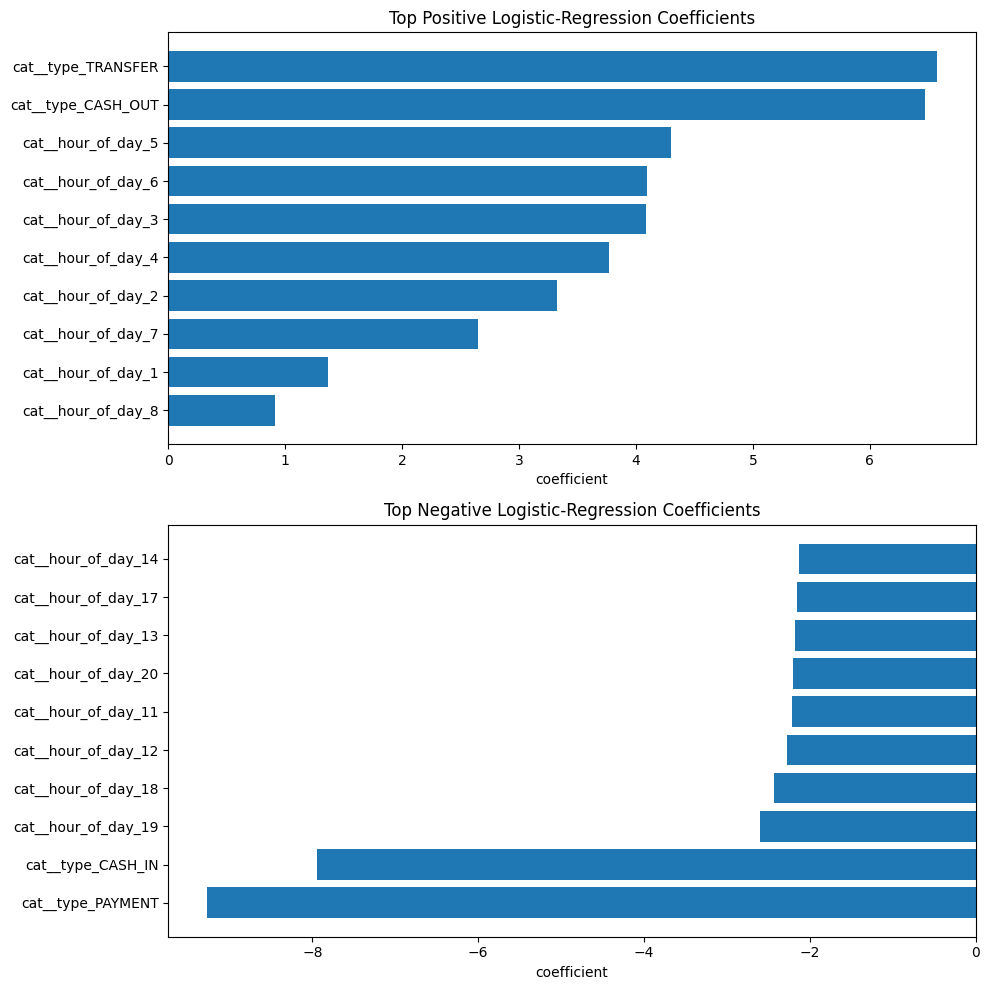

In [69]:
top_pos = logit_coef_df.sort_values('coefficient', ascending=False).head(10).iloc[::-1]
top_neg = logit_coef_df.sort_values('coefficient', ascending=True).head(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].barh(top_pos['feature'], top_pos['coefficient'])
axes[0].set_title('Top Positive Logistic-Regression Coefficients')
axes[0].set_xlabel('coefficient')

axes[1].barh(top_neg['feature'], top_neg['coefficient'])
axes[1].set_title('Top Negative Logistic-Regression Coefficients')
axes[1].set_xlabel('coefficient')

plt.tight_layout()
plt.show()

The coefficient results provide a transparent benchmark-level interpretation of the logistic model. Positive coefficients increase the model’s predicted fraud risk, while negative coefficients decrease it. In general, the signs should be consistent with the earlier exploratory analysis: high-risk transaction types, novelty-related features, and larger transaction amounts should contribute positively to fraud risk, while more established historical activity may reduce it. This interpretability is one of the main reasons logistic regression is a useful benchmark before moving to the more flexible XGBoost model.

## Section 3. Advanced XGBoost model and final review

The logistic-regression benchmark provides an interpretable reference point, but it remains a linear model. That limits its ability to capture non-linear interactions among transaction attributes, timing patterns, and behavioral-history features.

The purpose of this section is to evaluate whether a more flexible tree-based model can provide additional value beyond the best logistic-regression benchmark.

The advanced-model workflow will use:
- XGBoost as the model class,
- time-aware tuning logic,
- stability-aware model selection,
- and validation-based threshold selection before final holdout reporting.

### 3.1 Advanced-model feature set

The advanced model uses the same core transaction and behavioral feature family developed earlier in the notebook.

The feature set includes:

- `step`
- `type`
- `log_amount`
- `hour_of_day`
- `orig_is_first_seen`
- `dest_is_first_seen`
- `log_orig_prior_tx_count`
- `log_dest_prior_tx_count`
- `log_orig_prior_24h_tx_count`
- `log_dest_prior_24h_tx_count`

This keeps the advanced model grounded in the same feature-engineering framework while allowing a more flexible model class to capture non-linear interactions among these signals.

In [33]:
advanced_features = [
    'step',
    'type',
    'log_amount',
    'hour_of_day',
    'orig_is_first_seen',
    'dest_is_first_seen',
    'log_orig_prior_tx_count',
    'log_dest_prior_tx_count',
    'log_orig_prior_24h_tx_count',
    'log_dest_prior_24h_tx_count'
]

advanced_feature_summary = pd.DataFrame([
    {'metric': 'Advanced feature count', 'value': len(advanced_features)},
    {'metric': 'Advanced features', 'value': ', '.join(advanced_features)}
])

display(advanced_feature_summary)

,metric,value
0,Advanced feature count,10
1,Advanced features,"step, type, log_amount, hour_of_day, orig_is_f..."


### 3.2 Rolling time-based cross-validation

The advanced-model tuning process should remain time-aware. Random k-fold cross-validation is not appropriate here because it mixes earlier and later transactions in a way that is less realistic for a monitoring problem.

Instead, the XGBoost tuning stage uses rolling time-based cross-validation within the training set:

- each fold trains on an earlier window,
- and evaluates on a later validation window.

This makes the tuning process more consistent with the forward-looking nature of transaction monitoring.

In [34]:
def make_expanding_time_folds(df_in, step_col='step', min_train_hours=240, valid_window=48, step_stride=48):
    """
    Build expanding-window time-based CV folds inside the training set.
    """
    min_step = int(df_in[step_col].min())
    max_step = int(df_in[step_col].max())

    folds = []
    valid_start = min_step + min_train_hours

    while valid_start + valid_window - 1 <= max_step:
        train_start = min_step
        train_end = valid_start - 1
        valid_end = valid_start + valid_window - 1

        folds.append({
            'train_start': train_start,
            'train_end': train_end,
            'valid_start': valid_start,
            'valid_end': valid_end
        })

        valid_start += step_stride

    return folds


folds = make_expanding_time_folds(
    train_df,
    step_col='step',
    min_train_hours=240,   # first 10 days for initial training window
    valid_window=48,       # 2-day validation windows
    step_stride=48         # move forward 2 days each fold
)

fold_summary_rows = []
for i, fold in enumerate(folds, start=1):
    fold_train = train_df[
        (train_df['step'] >= fold['train_start']) &
        (train_df['step'] <= fold['train_end'])
    ]
    fold_valid = train_df[
        (train_df['step'] >= fold['valid_start']) &
        (train_df['step'] <= fold['valid_end'])
    ]

    fold_summary_rows.append({
        'fold': i,
        'train_range': f"{fold['train_start']} - {fold['train_end']}",
        'valid_range': f"{fold['valid_start']} - {fold['valid_end']}",
        'train_rows': len(fold_train),
        'valid_rows': len(fold_valid),
        'train_fraud': int(fold_train[TARGET].sum()),
        'valid_fraud': int(fold_valid[TARGET].sum())
    })

fold_summary_df = pd.DataFrame(fold_summary_rows)
display(fold_summary_df)

,fold,train_range,valid_range,train_rows,valid_rows,train_fraud,valid_fraud
0,1,1 - 240,241 - 288,3190681,767635,2719,560
1,2,1 - 288,289 - 336,3958316,826459,3279,488
2,3,1 - 336,337 - 384,4784775,776876,3767,502
3,4,1 - 384,385 - 432,5561651,446765,4269,588


### 3.3 Random search for XGBoost

The first tuning stage uses random search over a broad XGBoost parameter space.

This stage is used to:
- explore a wider range of hyperparameter settings,
- identify promising regions of the search space,
- and measure both performance and stability across rolling time folds.

In addition to average validation PR AUC, later selection will also consider:
- fold-to-fold variability, and
- train-to-validation generalization gap.

In [35]:
spw = (train_df[TARGET] == 0).sum() / max((train_df[TARGET] == 1).sum(), 1)

random_param_space = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.10],
    'n_estimators': [100, 150, 200, 300, 400],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.6, 0.8, 1.0],
    'gamma': [0, 0.5, 1, 2, 5]
}

random_param_list = list(
    ParameterSampler(
        random_param_space,
        n_iter=N_RANDOM_SEARCH,
        random_state=SEED
    )
)

print("Number of random-search candidates:", len(random_param_list))
print("scale_pos_weight:", round(spw, 4))

display(pd.DataFrame(random_param_list).head(10))

Number of random-search candidates: 40
scale_pos_weight: 1129.3457


,subsample,n_estimators,max_depth,learning_rate,gamma,colsample_bytree,colsample_bylevel
0,0.600000,400,4,0.030000,0.000000,0.600000,0.800000
1,0.600000,200,7,0.030000,0.500000,0.600000,0.600000
2,0.900000,150,4,0.010000,0.500000,0.800000,1.000000
3,0.800000,150,7,0.050000,0.500000,1.000000,1.000000
4,1.000000,150,4,0.010000,2.000000,0.900000,0.600000
5,0.600000,300,3,0.010000,0.000000,0.800000,0.600000
6,0.600000,100,7,0.100000,0.500000,0.600000,0.800000
7,1.000000,300,5,0.050000,5.000000,0.700000,1.000000
8,0.800000,200,6,0.010000,0.000000,0.800000,0.800000
9,0.700000,150,3,0.080000,0.000000,1.000000,1.000000


#### Evaluate one XGBoost parameter set across rolling time-based folds

In [36]:
def evaluate_xgb_params_on_folds(df_in, folds, params, features, target=TARGET):
    """
    Evaluate one XGBoost parameter set across rolling time-based CV folds.
    """
    train_pr_aucs = []
    valid_pr_aucs = []
    train_roc_aucs = []
    valid_roc_aucs = []

    categorical_for_xgb = [c for c in features if c in ['type', 'hour_of_day']]

    for fold in folds:
        fold_train = df_in[
            (df_in['step'] >= fold['train_start']) &
            (df_in['step'] <= fold['train_end'])
        ].copy()

        fold_valid = df_in[
            (df_in['step'] >= fold['valid_start']) &
            (df_in['step'] <= fold['valid_end'])
        ].copy()

        X_fold_train = pd.get_dummies(
            fold_train[features],
            columns=categorical_for_xgb,
            drop_first=False
        )
        X_fold_valid = pd.get_dummies(
            fold_valid[features],
            columns=categorical_for_xgb,
            drop_first=False
        )

        X_fold_train, X_fold_valid = X_fold_train.align(
            X_fold_valid,
            join='left',
            axis=1,
            fill_value=0
        )

        y_fold_train = fold_train[target].copy()
        y_fold_valid = fold_valid[target].copy()

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=SEED,
            n_jobs=-1,
            scale_pos_weight=spw,
            **params
        )

        model.fit(X_fold_train, y_fold_train)

        train_scores = model.predict_proba(X_fold_train)[:, 1]
        valid_scores = model.predict_proba(X_fold_valid)[:, 1]

        train_pr_aucs.append(average_precision_score(y_fold_train, train_scores))
        valid_pr_aucs.append(average_precision_score(y_fold_valid, valid_scores))

        train_roc_aucs.append(roc_auc_score(y_fold_train, train_scores))
        valid_roc_aucs.append(roc_auc_score(y_fold_valid, valid_scores))

    mean_train_pr = float(np.mean(train_pr_aucs))
    mean_valid_pr = float(np.mean(valid_pr_aucs))
    mean_train_roc = float(np.mean(train_roc_aucs))
    mean_valid_roc = float(np.mean(valid_roc_aucs))

    valid_pr_range = float(np.max(valid_pr_aucs) - np.min(valid_pr_aucs))
    relative_gap = float((mean_train_pr - mean_valid_pr) / max(mean_valid_pr, 1e-12))
    std_valid_pr = float(np.std(valid_pr_aucs))

    return {
        **params,
        'mean_train_pr_auc': mean_train_pr,
        'mean_valid_pr_auc': mean_valid_pr,
        'mean_train_roc_auc': mean_train_roc,
        'mean_valid_roc_auc': mean_valid_roc,
        'std_valid_pr_auc': std_valid_pr,
        'valid_pr_auc_max': float(np.max(valid_pr_aucs)),
        'valid_pr_auc_min': float(np.min(valid_pr_aucs)),
        'test_pr_auc_range': valid_pr_range,
        'relative_gap': relative_gap,
        'fold_train_pr_aucs': train_pr_aucs,
        'fold_valid_pr_aucs': valid_pr_aucs
    }

#### Run the random-search loop

In [37]:
random_search_results = []

for i, params in enumerate(random_param_list, start=1):
    print(f"Running random-search candidate {i} / {len(random_param_list)}: {params}")

    res = evaluate_xgb_params_on_folds(
        df_in=train_df,
        folds=folds,
        params=params,
        features=advanced_features,
        target=TARGET
    )
    random_search_results.append(res)

rs_results_df = pd.DataFrame(random_search_results).sort_values(
    ['mean_valid_pr_auc', 'mean_valid_roc_auc'],
    ascending=[False, False]
).reset_index(drop=True)

display(
    rs_results_df[[
        'max_depth',
        'learning_rate',
        'n_estimators',
        'subsample',
        'colsample_bytree',
        'colsample_bylevel',
        'gamma',
        'mean_train_pr_auc',
        'mean_valid_pr_auc',
        'mean_valid_roc_auc',
        'std_valid_pr_auc',
        'test_pr_auc_range',
        'relative_gap'
    ]]
)

Running random-search candidate 1 / 40: {'subsample': 0.6, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6, 'colsample_bylevel': 0.8}
Running random-search candidate 2 / 40: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6, 'colsample_bylevel': 0.6}
Running random-search candidate 3 / 40: {'subsample': 0.9, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8, 'colsample_bylevel': 1.0}
Running random-search candidate 4 / 40: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0, 'colsample_bylevel': 1.0}
Running random-search candidate 5 / 40: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 2, 'colsample_bytree': 0.9, 'colsample_bylevel': 0.6}
Running random-search candidate 6 / 40: {'subsample': 0.6, 'n_estimators': 300, 'max

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,colsample_bylevel,gamma,mean_train_pr_auc,mean_valid_pr_auc,mean_valid_roc_auc,std_valid_pr_auc,test_pr_auc_range,relative_gap
0,3,0.080000,400,0.900000,0.600000,0.800000,0.000000,0.489966,0.422993,0.973463,0.048666,0.137134,0.158331
1,5,0.050000,300,1.000000,0.800000,1.000000,0.000000,0.507278,0.415119,0.972786,0.072008,0.203353,0.222006
2,3,0.080000,300,1.000000,0.700000,0.800000,0.500000,0.453737,0.408449,0.973572,0.054917,0.154529,0.110879
3,5,0.050000,300,1.000000,0.700000,1.000000,5.000000,0.500530,0.405691,0.972843,0.082014,0.231486,0.233772
4,5,0.100000,150,0.900000,0.600000,0.600000,2.000000,0.485093,0.405558,0.973427,0.083079,0.231168,0.196113
5,5,0.080000,200,0.900000,0.800000,1.000000,1.000000,0.521162,0.402704,0.972019,0.064642,0.178390,0.294155
6,7,0.030000,400,0.800000,0.600000,0.600000,5.000000,0.535256,0.396616,0.972666,0.089441,0.248910,0.349559
7,5,0.100000,300,0.900000,1.000000,0.800000,0.000000,0.584614,0.392651,0.966506,0.059822,0.163920,0.488890
8,3,0.080000,150,0.700000,1.000000,1.000000,0.000000,0.407110,0.391933,0.973575,0.042615,0.118801,0.038722
9,5,0.080000,150,0.700000,0.700000,0.600000,0.000000,0.466039,0.385449,0.973632,0.076921,0.217179,0.209079


#### Apply stability filtering

In [38]:
q75_range = rs_results_df['test_pr_auc_range'].quantile(0.75)
q75_gap = rs_results_df['relative_gap'].quantile(0.75)

stable_candidates = rs_results_df[
    (rs_results_df['test_pr_auc_range'] <= q75_range) &
    (rs_results_df['relative_gap'] <= q75_gap)
].copy()

stable_candidates = stable_candidates.sort_values(
    ['mean_valid_pr_auc', 'mean_valid_roc_auc'],
    ascending=[False, False]
).reset_index(drop=True)

stability_summary = pd.DataFrame([
    {'metric': 'q75 test_pr_auc_range', 'value': q75_range},
    {'metric': 'q75 relative_gap', 'value': q75_gap},
    {'metric': 'stable candidates retained', 'value': len(stable_candidates)}
])

display(stability_summary)

display(
    stable_candidates[[
        'max_depth',
        'learning_rate',
        'n_estimators',
        'subsample',
        'colsample_bytree',
        'colsample_bylevel',
        'gamma',
        'mean_valid_pr_auc',
        'test_pr_auc_range',
        'relative_gap'
    ]].head(10)
)

,metric,value
0,q75 test_pr_auc_range,0.243876
1,q75 relative_gap,0.501973
2,stable candidates retained,23.000000


,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,colsample_bylevel,gamma,mean_valid_pr_auc,test_pr_auc_range,relative_gap
0,3,0.080000,400,0.900000,0.600000,0.800000,0.000000,0.422993,0.137134,0.158331
1,5,0.050000,300,1.000000,0.800000,1.000000,0.000000,0.415119,0.203353,0.222006
2,3,0.080000,300,1.000000,0.700000,0.800000,0.500000,0.408449,0.154529,0.110879
3,5,0.050000,300,1.000000,0.700000,1.000000,5.000000,0.405691,0.231486,0.233772
4,5,0.100000,150,0.900000,0.600000,0.600000,2.000000,0.405558,0.231168,0.196113
5,5,0.080000,200,0.900000,0.800000,1.000000,1.000000,0.402704,0.178390,0.294155
6,5,0.100000,300,0.900000,1.000000,0.800000,0.000000,0.392651,0.163920,0.488890
7,3,0.080000,150,0.700000,1.000000,1.000000,0.000000,0.391933,0.118801,0.038722
8,5,0.080000,150,0.700000,0.700000,0.600000,0.000000,0.385449,0.217179,0.209079
9,5,0.080000,200,0.600000,0.600000,0.600000,1.000000,0.383551,0.216982,0.251901


### 3.4 Narrowed grid search

After random search, the next step is to refine the search around the strongest stable candidates.

A full grid across all XGBoost hyperparameters would create unnecessary runtime, so the narrowed grid is restricted to the most influential parameters:

- `max_depth`
- `learning_rate`
- `n_estimators`
- `subsample`

The remaining parameters are fixed at stable central values from the strongest random-search candidates:

- `colsample_bytree`
- `colsample_bylevel`
- `gamma`

The local grid is constructed from the mean and standard deviation of the strongest stable candidates. This keeps the second-stage search compact while still focusing on the most promising region of the search space.

#### Construct the narrowed grid using mean ± std

In [39]:
top_grid_seed = stable_candidates.head(min(5, len(stable_candidates))).copy()

fixed_colsample_bytree = round(float(top_grid_seed['colsample_bytree'].median()), 2)
fixed_colsample_bylevel = round(float(top_grid_seed['colsample_bylevel'].median()), 2)
fixed_gamma = round(float(top_grid_seed['gamma'].median()), 2)

def generate_grid_values(param, mean_val, std_val):
    if pd.isna(std_val) or std_val == 0:
        if param == 'max_depth':
            std_val = 1
        elif param == 'n_estimators':
            std_val = 50
        elif param == 'learning_rate':
            std_val = 0.02
        elif param == 'subsample':
            std_val = 0.1

    if param == 'max_depth':
        low = max(2, int(round(mean_val - std_val)))
        mid = int(round(mean_val))
        high = int(round(mean_val + std_val))
        return sorted(list(set([low, mid, high])))

    elif param == 'n_estimators':
        low = max(50, int(round((mean_val - std_val) / 50) * 50))
        mid = int(round(mean_val / 50) * 50)
        high = int(round((mean_val + std_val) / 50) * 50)
        return sorted(list(set([low, mid, high])))

    elif param == 'learning_rate':
        low = max(0.001, round(mean_val - std_val, 3))
        mid = round(mean_val, 3)
        high = round(mean_val + std_val, 3)
        return sorted(list(set([low, mid, high])))

    elif param == 'subsample':
        low = round(max(0.5, mean_val - std_val), 2)
        high = round(min(1.0, mean_val + std_val), 2)
        return sorted(list(set([low, high])))

    else:
        raise ValueError(f"Unsupported parameter: {param}")

grid_params = ['max_depth', 'learning_rate', 'n_estimators', 'subsample']

narrow_param_grid = {
    'colsample_bytree': [fixed_colsample_bytree],
    'colsample_bylevel': [fixed_colsample_bylevel],
    'gamma': [max(0.0, fixed_gamma)]
}

for p in grid_params:
    p_mean = top_grid_seed[p].mean()
    p_std = top_grid_seed[p].std()
    narrow_param_grid[p] = generate_grid_values(p, p_mean, p_std)

narrow_param_grid = {
    'max_depth': narrow_param_grid['max_depth'],
    'learning_rate': narrow_param_grid['learning_rate'],
    'n_estimators': narrow_param_grid['n_estimators'],
    'subsample': narrow_param_grid['subsample'],
    'colsample_bytree': narrow_param_grid['colsample_bytree'],
    'colsample_bylevel': narrow_param_grid['colsample_bylevel'],
    'gamma': narrow_param_grid['gamma']
}

narrow_grid_summary = pd.DataFrame([
    {'parameter': p, 'grid_values': narrow_param_grid[p]} for p in narrow_param_grid
])

display(narrow_grid_summary)

,parameter,grid_values
0,max_depth,"[3, 4, 5]"
1,learning_rate,"[0.05, 0.072, 0.094]"
2,n_estimators,"[200, 300, 400]"
3,subsample,"[0.91, 1.0]"
4,colsample_bytree,[0.7]
5,colsample_bylevel,[0.8]
6,gamma,[0.5]


#### Expand the narrowed grid into concrete parameter combinations

In [40]:
grid_param_list = [
    dict(zip(narrow_param_grid.keys(), values))
    for values in product(*narrow_param_grid.values())
]

print("Number of narrowed-grid candidates:", len(grid_param_list))
display(pd.DataFrame(grid_param_list).head(10))

Number of narrowed-grid candidates: 54


,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,colsample_bylevel,gamma
0,3,0.050000,200,0.910000,0.700000,0.800000,0.500000
1,3,0.050000,200,1.000000,0.700000,0.800000,0.500000
2,3,0.050000,300,0.910000,0.700000,0.800000,0.500000
3,3,0.050000,300,1.000000,0.700000,0.800000,0.500000
4,3,0.050000,400,0.910000,0.700000,0.800000,0.500000
5,3,0.050000,400,1.000000,0.700000,0.800000,0.500000
6,3,0.072000,200,0.910000,0.700000,0.800000,0.500000
7,3,0.072000,200,1.000000,0.700000,0.800000,0.500000
8,3,0.072000,300,0.910000,0.700000,0.800000,0.500000
9,3,0.072000,300,1.000000,0.700000,0.800000,0.500000


#### Run the narrowed-grid search across rolling time-based folds

In [41]:
grid_search_results = []

for i, params in enumerate(grid_param_list, start=1):
    print(f"Running narrowed-grid candidate {i} / {len(grid_param_list)}: {params}")

    res = evaluate_xgb_params_on_folds(
        df_in=train_df,
        folds=folds,
        params=params,
        features=advanced_features,
        target=TARGET
    )
    grid_search_results.append(res)

grid_results_df = pd.DataFrame(grid_search_results).sort_values(
    ['mean_valid_pr_auc', 'mean_valid_roc_auc'],
    ascending=[False, False]
).reset_index(drop=True)

display(
    grid_results_df[[
        'max_depth',
        'learning_rate',
        'n_estimators',
        'subsample',
        'colsample_bytree',
        'colsample_bylevel',
        'gamma',
        'mean_train_pr_auc',
        'mean_valid_pr_auc',
        'mean_valid_roc_auc',
        'std_valid_pr_auc',
        'test_pr_auc_range',
        'relative_gap'
    ]]
)

Running narrowed-grid candidate 1 / 54: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 200, 'subsample': np.float64(0.91), 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'gamma': 0.5}
Running narrowed-grid candidate 2 / 54: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'gamma': 0.5}
Running narrowed-grid candidate 3 / 54: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 300, 'subsample': np.float64(0.91), 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'gamma': 0.5}
Running narrowed-grid candidate 4 / 54: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 300, 'subsample': 1.0, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'gamma': 0.5}
Running narrowed-grid candidate 5 / 54: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 400, 'subsample': np.float64(0.91), 'colsample_bytree': 0.7, 'colsample_bylevel': 

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,colsample_bylevel,gamma,mean_train_pr_auc,mean_valid_pr_auc,mean_valid_roc_auc,std_valid_pr_auc,test_pr_auc_range,relative_gap
0,4,0.094000,400,1.000000,0.700000,0.800000,0.500000,0.556819,0.443119,0.971300,0.036371,0.095491,0.256592
1,4,0.094000,300,1.000000,0.700000,0.800000,0.500000,0.529476,0.435963,0.972300,0.050477,0.141530,0.214497
2,4,0.072000,400,1.000000,0.700000,0.800000,0.500000,0.531331,0.434023,0.972242,0.045363,0.127467,0.224200
3,3,0.094000,400,1.000000,0.700000,0.800000,0.500000,0.506464,0.430849,0.973175,0.032794,0.088308,0.175503
4,4,0.072000,400,0.910000,0.700000,0.800000,0.500000,0.531554,0.427187,0.972087,0.046286,0.124355,0.244310
5,4,0.072000,300,1.000000,0.700000,0.800000,0.500000,0.500831,0.425643,0.973340,0.063084,0.177598,0.176646
6,3,0.072000,400,1.000000,0.700000,0.800000,0.500000,0.472475,0.425305,0.973262,0.047670,0.133063,0.110910
7,5,0.072000,300,1.000000,0.700000,0.800000,0.500000,0.546861,0.424434,0.972426,0.056262,0.155466,0.288448
8,4,0.050000,400,1.000000,0.700000,0.800000,0.500000,0.491193,0.424299,0.973883,0.057158,0.159425,0.157659
9,3,0.094000,300,1.000000,0.700000,0.800000,0.500000,0.477828,0.423692,0.973718,0.036592,0.099626,0.127772


### 3.5 Validation-based comparison of the top XGBoost candidates

After the narrowed-grid search, the strongest XGBoost candidates are carried forward to a validation-based comparison stage.

For each of the top candidates:

- the model is fit on `train`
- validation ranking metrics are computed
- thresholds are swept on `validation`
- operational metrics are computed for each threshold

This stage is intended to combine:
- threshold-free ranking quality,
- threshold-based operational performance,
- and practical alert-burden measures.

#### Select the best XGBoost candidate on validation

In [42]:
top_xgb_candidates = grid_results_df.head(min(10, len(grid_results_df))).copy().reset_index(drop=True)
top_xgb_candidates['candidate_id'] = [f'xgb_{i+1}' for i in range(len(top_xgb_candidates))]

categorical_for_xgb = [c for c in advanced_features if c in ['type', 'hour_of_day']]

X_train_xgb_valsel = pd.get_dummies(
    train_df[advanced_features],
    columns=categorical_for_xgb,
    drop_first=False
)
X_valid_xgb_valsel = pd.get_dummies(
    valid_df[advanced_features],
    columns=categorical_for_xgb,
    drop_first=False
)

X_train_xgb_valsel, X_valid_xgb_valsel = X_train_xgb_valsel.align(
    X_valid_xgb_valsel,
    join='left',
    axis=1,
    fill_value=0
)

y_train_xgb_valsel = train_df[TARGET].copy()
y_valid_xgb_valsel = valid_df[TARGET].copy()

candidate_validation_rows = []
candidate_valid_score_store = {}

for _, row in top_xgb_candidates.iterrows():
    candidate_id = row['candidate_id']

    params = {
        'max_depth': int(row['max_depth']),
        'learning_rate': float(row['learning_rate']),
        'n_estimators': int(row['n_estimators']),
        'subsample': float(row['subsample']),
        'colsample_bytree': float(row['colsample_bytree']),
        'colsample_bylevel': float(row['colsample_bylevel']),
        'gamma': float(row['gamma'])
    }

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=spw,
        **params
    )

    model.fit(X_train_xgb_valsel, y_train_xgb_valsel)
    valid_scores = model.predict_proba(X_valid_xgb_valsel)[:, 1]

    candidate_valid_score_store[candidate_id] = {
        'params': params,
        'model': model,
        'valid_scores': valid_scores
    }

    candidate_validation_rows.append({
        'candidate_id': candidate_id,
        'valid_pr_auc': average_precision_score(y_valid_xgb_valsel, valid_scores),
        'valid_roc_auc': roc_auc_score(y_valid_xgb_valsel, valid_scores),
        'cv_mean_valid_pr_auc': row['mean_valid_pr_auc'],
        'cv_mean_valid_roc_auc': row['mean_valid_roc_auc'],
        'cv_test_pr_auc_range': row['test_pr_auc_range'],
        'cv_relative_gap': row['relative_gap'],
        **params
    })

candidate_validation_df = pd.DataFrame(candidate_validation_rows).sort_values(
    ['valid_pr_auc', 'cv_mean_valid_pr_auc', 'cv_test_pr_auc_range', 'cv_relative_gap'],
    ascending=[False, False, True, True]
).reset_index(drop=True)

display(candidate_validation_df)

,candidate_id,valid_pr_auc,valid_roc_auc,cv_mean_valid_pr_auc,cv_mean_valid_roc_auc,cv_test_pr_auc_range,cv_relative_gap,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,colsample_bylevel,gamma
0,xgb_9,0.534564,0.975744,0.424299,0.973883,0.159425,0.157659,4,0.050000,400,1.000000,0.700000,0.800000,0.500000
1,xgb_4,0.526722,0.975707,0.430849,0.973175,0.088308,0.175503,3,0.094000,400,1.000000,0.700000,0.800000,0.500000
2,xgb_5,0.522211,0.975666,0.427187,0.972087,0.124355,0.244310,4,0.072000,400,0.910000,0.700000,0.800000,0.500000
3,xgb_6,0.518278,0.975986,0.425643,0.973340,0.177598,0.176646,4,0.072000,300,1.000000,0.700000,0.800000,0.500000
4,xgb_1,0.516691,0.973940,0.443119,0.971300,0.095491,0.256592,4,0.094000,400,1.000000,0.700000,0.800000,0.500000
5,xgb_10,0.515984,0.975315,0.423692,0.973718,0.099626,0.127772,3,0.094000,300,1.000000,0.700000,0.800000,0.500000
6,xgb_8,0.514325,0.972480,0.424434,0.972426,0.155466,0.288448,5,0.072000,300,1.000000,0.700000,0.800000,0.500000
7,xgb_3,0.513970,0.974644,0.434023,0.972242,0.127467,0.224200,4,0.072000,400,1.000000,0.700000,0.800000,0.500000
8,xgb_2,0.510183,0.974703,0.435963,0.972300,0.141530,0.214497,4,0.094000,300,1.000000,0.700000,0.800000,0.500000
9,xgb_7,0.505166,0.976756,0.425305,0.973262,0.133063,0.110910,3,0.072000,400,1.000000,0.700000,0.800000,0.500000


#### Threshold sweep for each top candidate on validation

In [43]:
candidate_threshold_rows = []

valid_eval_df = valid_df[['transaction_id', 'amount', TARGET]].copy().reset_index(drop=True)

for _, row in candidate_validation_df.iterrows():
    candidate_id = row['candidate_id']
    valid_scores = candidate_valid_score_store[candidate_id]['valid_scores']

    threshold_df = evaluate_thresholds(
        y_true=y_valid_xgb_valsel,
        scores=valid_scores,
        fn_cost=FN_COST,
        fp_cost=FP_COST,
        n_thresholds=50
    )

    for _, thr_row in threshold_df.iterrows():
        thr = float(thr_row['threshold'])
        preds = (valid_scores >= thr).astype(int)

        incremental_negative_alert_mask = (y_valid_xgb_valsel.to_numpy() == 0) & (preds == 1)
        incremental_negative_alert_count = int(incremental_negative_alert_mask.sum())
        incremental_negative_alert_amount = float(
            valid_eval_df.loc[incremental_negative_alert_mask, 'amount'].sum()
        )

        negative_pool = thr_row['fn'] + thr_row['tn']
        false_omission_rate = (
            float(thr_row['fn'] / negative_pool) if negative_pool > 0 else 0.0
        )

        candidate_threshold_rows.append({
            'candidate_id': candidate_id,
            'valid_pr_auc': row['valid_pr_auc'],
            'valid_roc_auc': row['valid_roc_auc'],
            'cv_mean_valid_pr_auc': row['cv_mean_valid_pr_auc'],
            'cv_test_pr_auc_range': row['cv_test_pr_auc_range'],
            'cv_relative_gap': row['cv_relative_gap'],
            'threshold': thr_row['threshold'],
            'tp': int(thr_row['tp']),
            'fp': int(thr_row['fp']),
            'fn': int(thr_row['fn']),
            'tn': int(thr_row['tn']),
            'precision': float(thr_row['precision']),
            'recall': float(thr_row['recall']),
            'f1': float(thr_row['f1']),
            'f2': float(thr_row['f2']),
            'alert_volume': int(thr_row['alert_volume']),
            'alert_rate': float(thr_row['alert_rate']),
            'expected_cost': float(thr_row['expected_cost']),
            'incremental_negative_alert_count': incremental_negative_alert_count,
            'incremental_negative_alert_amount': incremental_negative_alert_amount,
            'false_omission_rate': false_omission_rate
        })

candidate_threshold_df = pd.DataFrame(candidate_threshold_rows)

display(candidate_threshold_df.head(20))
print("Candidate-threshold rows:", len(candidate_threshold_df))

,candidate_id,valid_pr_auc,valid_roc_auc,cv_mean_valid_pr_auc,cv_test_pr_auc_range,cv_relative_gap,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost,incremental_negative_alert_count,incremental_negative_alert_amount,false_omission_rate
0,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.010000,1016,66687,0,93177,0.015007,1.000000,0.029570,0.070785,67703,0.420829,"333,435.000000",66687,"19,491,461,512.430000",0.000000
1,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.030000,1016,65698,0,94166,0.015229,1.000000,0.030001,0.071774,66714,0.414682,"328,490.000000",65698,"18,691,298,140.549999",0.000000
2,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.050000,1016,64142,0,95722,0.015593,1.000000,0.030707,0.073387,65158,0.405010,"320,710.000000",64142,"16,962,214,549.590000",0.000000
3,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.070000,1016,62319,0,97545,0.016042,1.000000,0.031577,0.075372,63335,0.393679,"311,595.000000",62319,"15,415,504,909.150002",0.000000
4,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.090000,1016,60772,0,99092,0.016443,1.000000,0.032355,0.077143,61788,0.384063,"303,860.000000",60772,"14,284,669,903.780001",0.000000
5,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.110000,1016,59311,0,100553,0.016842,1.000000,0.033125,0.078893,60327,0.374981,"296,555.000000",59311,"13,533,493,549.380001",0.000000
6,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.130000,1016,57955,0,101909,0.017229,1.000000,0.033874,0.080590,58971,0.366553,"289,775.000000",57955,"12,995,242,022.139999",0.000000
7,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.150000,1016,56846,0,103018,0.017559,1.000000,0.034512,0.082033,57862,0.359659,"284,230.000000",56846,"12,530,133,081.009998",0.000000
8,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.170000,1016,56200,0,103664,0.017757,1.000000,0.034895,0.082898,57216,0.355644,"281,000.000000",56200,"12,258,171,317.040001",0.000000
9,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.190000,1016,55499,0,104365,0.017978,1.000000,0.035320,0.083857,56515,0.351287,"277,495.000000",55499,"11,944,062,940.299999",0.000000


Candidate-threshold rows: 500


#### Pick the best threshold for each candidate and create the requested plots

,candidate_id,valid_pr_auc,valid_roc_auc,cv_mean_valid_pr_auc,cv_test_pr_auc_range,cv_relative_gap,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost,incremental_negative_alert_count,incremental_negative_alert_amount,false_omission_rate
0,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.930000,857,4912,159,154952,0.148553,0.843504,0.252616,0.435777,5769,0.035859,"104,060.000000",4912,"2,356,615,371.890000",0.001025
1,xgb_4,0.526722,0.975707,0.430849,0.088308,0.175503,0.910000,868,4547,148,155317,0.160295,0.854331,0.269942,0.457854,5415,0.033659,"96,735.000000",4547,"2,324,371,887.050000",0.000952
2,xgb_5,0.522211,0.975666,0.427187,0.124355,0.244310,0.910000,882,6685,134,153179,0.116559,0.868110,0.205523,0.379159,7567,0.047035,"100,425.000000",6685,"2,602,461,891.510000",0.000874
3,xgb_6,0.518278,0.975986,0.425643,0.177598,0.176646,0.930000,866,5607,150,154257,0.133786,0.852362,0.231273,0.410933,6473,0.040235,"103,035.000000",5607,"2,505,387,245.450000",0.000971
4,xgb_1,0.516691,0.973940,0.443119,0.095491,0.256592,0.850000,864,5401,152,154463,0.137909,0.850394,0.237330,0.418240,6265,0.038942,"103,005.000000",5401,"2,434,574,022.720000",0.000983
5,xgb_10,0.515984,0.975315,0.423692,0.099626,0.127772,0.930000,872,5482,144,154382,0.137236,0.858268,0.236635,0.418506,6354,0.039495,"99,410.000000",5482,"2,300,677,599.920000",0.000932
6,xgb_8,0.514325,0.972480,0.424434,0.155466,0.288448,0.890000,882,8294,134,151570,0.096120,0.868110,0.173077,0.333082,9176,0.057036,"108,470.000000",8294,"2,948,259,484.580000",0.000883
7,xgb_3,0.513970,0.974644,0.434023,0.127467,0.224200,0.890000,898,8997,118,150867,0.090753,0.883858,0.164605,0.321656,9895,0.061505,"103,985.000000",8997,"3,107,886,641.680000",0.000782
8,xgb_2,0.510183,0.974703,0.435963,0.141530,0.214497,0.930000,879,6566,137,153298,0.118066,0.865157,0.207777,0.381875,7445,0.046277,"101,330.000000",6566,"2,657,051,421.310000",0.000893
9,xgb_7,0.505166,0.976756,0.425305,0.133063,0.110910,0.950000,852,3511,164,156353,0.195278,0.838583,0.316788,0.505518,4363,0.027120,"99,555.000000",3511,"1,852,215,408.130000",0.001048


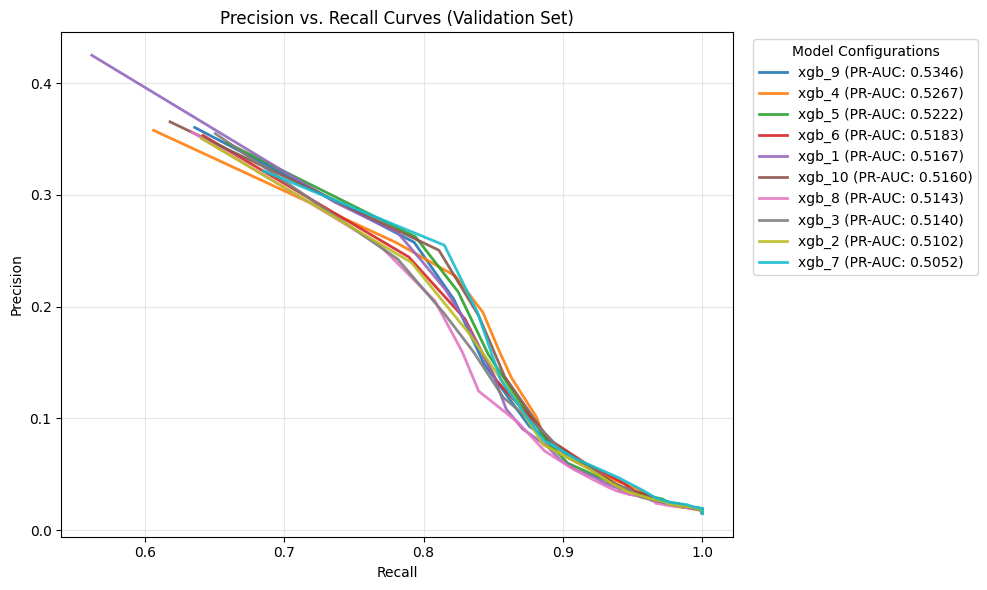

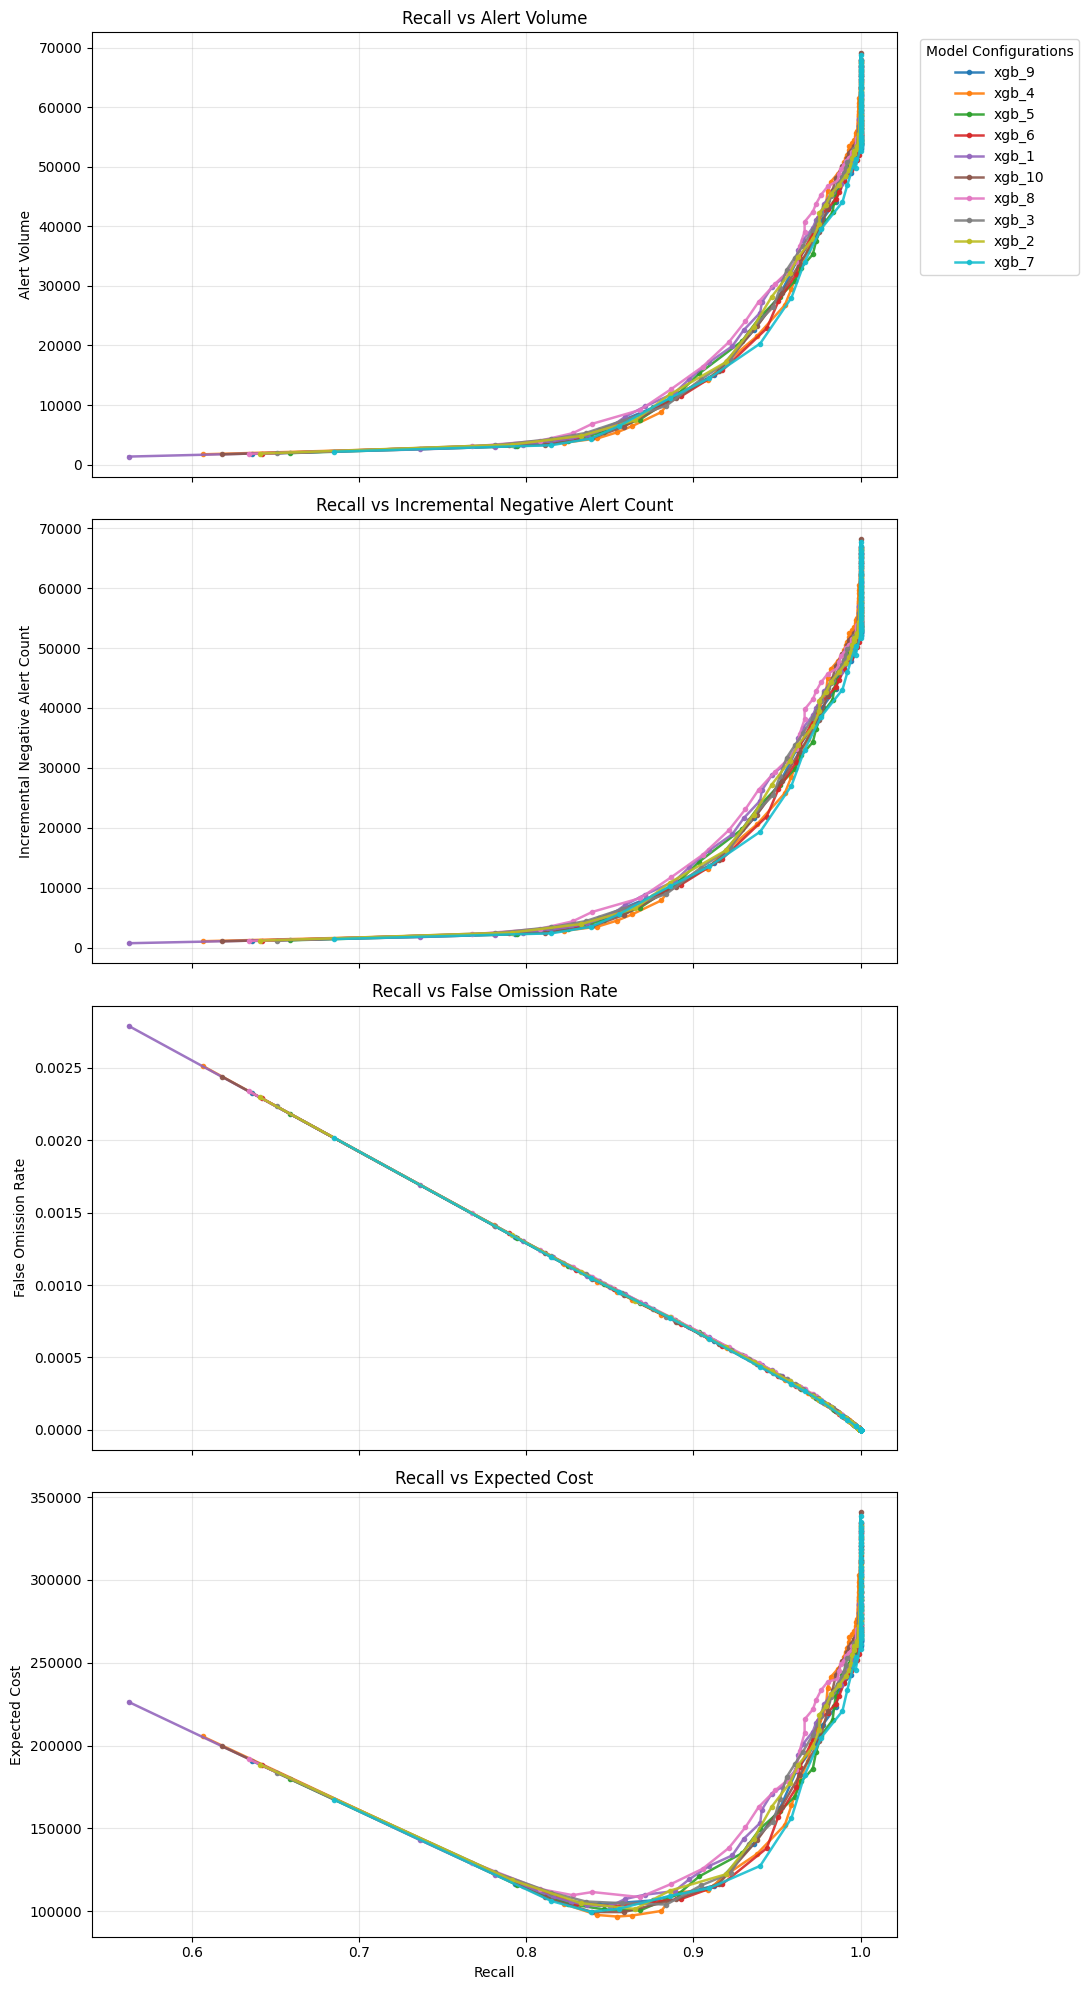

In [54]:
# Best threshold per candidate by expected cost
candidate_best_threshold_df = (
    candidate_threshold_df
    .sort_values(
        ['candidate_id', 'expected_cost', 'f2', 'false_omission_rate', 'alert_volume'],
        ascending=[True, True, False, True, True]
    )
    .groupby('candidate_id', as_index=False)
    .head(1)
    .sort_values(['valid_pr_auc', 'expected_cost'], ascending=[False, True])
    .reset_index(drop=True)
)

display(candidate_best_threshold_df)

# ---------------------------------------------------------
# Plot 1: Precision–Recall curves of top candidates
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plot_candidates = (
    candidate_validation_df
    .sort_values('valid_pr_auc', ascending=False)['candidate_id']
    .tolist()
)

for cid in plot_candidates:
    curve_df = (
        candidate_threshold_df[candidate_threshold_df['candidate_id'] == cid]
        .sort_values('recall')
        .copy()
    )

    pr_auc_value = curve_df['valid_pr_auc'].iloc[0]

    plt.plot(
        curve_df['recall'],
        curve_df['precision'],
        linewidth=2,
        alpha=0.9,
        label=f"{cid} (PR-AUC: {pr_auc_value:.4f})"
    )

plt.title('Precision vs. Recall Curves (Validation Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.legend(title='Model Configurations', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plots 2–5: Recall vs business / operational metrics
# ---------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(11, 20), sharex=True)

plot_specs = [
    ('alert_volume', 'Recall vs Alert Volume', 'Alert Volume'),
    ('incremental_negative_alert_count', 'Recall vs Incremental Negative Alert Count', 'Incremental Negative Alert Count'),
    ('false_omission_rate', 'Recall vs False Omission Rate', 'False Omission Rate'),
    ('expected_cost', 'Recall vs Expected Cost', 'Expected Cost')
]

for ax, (metric_col, title, ylabel) in zip(axes, plot_specs):
    for cid in plot_candidates:
        curve_df = (
            candidate_threshold_df[candidate_threshold_df['candidate_id'] == cid]
            .sort_values('recall')
            .copy()
        )

        ax.plot(
            curve_df['recall'],
            curve_df[metric_col],
            marker='o',
            markersize=3,
            linewidth=1.8,
            alpha=0.9,
            label=cid
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Recall')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title='Model Configurations', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

The expected-cost curves show a clear trade-off across recall levels. At low recall, expected cost is high because too many fraud cases are missed. As recall increases, cost declines because false negatives are reduced. Beyond a certain point, however, pushing recall higher leads to additional alert burden and more false positives, causing expected cost to rise again. In this validation analysis, the minimum-cost region appears around recall 0.84–0.86 for several of the top XGBoost candidates.

### 3.6 Final XGBoost model and threshold selection

Each top XGBoost candidate is now represented by:
- a validation PR AUC / ROC AUC profile,
- a best threshold selected on validation,
- and a set of operational metrics at that threshold.

The final selection is based primarily on:
- low expected cost,
- strong validation PR AUC,
- low false omission rate,
- and reasonable alert burden.

After the final candidate and threshold are selected, the model will be retrained on `train + validation`, and the locked threshold will be applied once to the holdout set.

In [50]:
final_xgb_choice_df = candidate_best_threshold_df.sort_values(
    ['valid_pr_auc', 'expected_cost', 'false_omission_rate', 'incremental_negative_alert_count'],
    ascending=[False, True, True, True]
).reset_index(drop=True)

display(final_xgb_choice_df)

best_xgb_candidate_id = final_xgb_choice_df.loc[0, 'candidate_id']
chosen_threshold_xgb = float(final_xgb_choice_df.loc[0, 'threshold'])

best_xgb_candidate_params = candidate_valid_score_store[best_xgb_candidate_id]['params']

final_xgb_selection_summary = pd.DataFrame([
    {'metric': 'Selected candidate_id', 'value': best_xgb_candidate_id},
    {'metric': 'Chosen threshold (from validation)', 'value': chosen_threshold_xgb},
    {'metric': 'Validation PR AUC', 'value': final_xgb_choice_df.loc[0, 'valid_pr_auc']},
    {'metric': 'Validation ROC AUC', 'value': final_xgb_choice_df.loc[0, 'valid_roc_auc']},
    {'metric': 'Expected cost', 'value': final_xgb_choice_df.loc[0, 'expected_cost']},
    {'metric': 'Alert volume', 'value': final_xgb_choice_df.loc[0, 'alert_volume']},
    {'metric': 'Incremental negative alert count(False Positive)', 'value': final_xgb_choice_df.loc[0, 'incremental_negative_alert_count']},
    {'metric': 'False omission rate', 'value': final_xgb_choice_df.loc[0, 'false_omission_rate']}
])

display(final_xgb_selection_summary)
print("Selected XGBoost params:", best_xgb_candidate_params)

,candidate_id,valid_pr_auc,valid_roc_auc,cv_mean_valid_pr_auc,cv_test_pr_auc_range,cv_relative_gap,threshold,tp,fp,fn,tn,precision,recall,f1,f2,alert_volume,alert_rate,expected_cost,incremental_negative_alert_count,incremental_negative_alert_amount,false_omission_rate
0,xgb_9,0.534564,0.975744,0.424299,0.159425,0.157659,0.930000,857,4912,159,154952,0.148553,0.843504,0.252616,0.435777,5769,0.035859,"104,060.000000",4912,"2,356,615,371.890000",0.001025
1,xgb_4,0.526722,0.975707,0.430849,0.088308,0.175503,0.910000,868,4547,148,155317,0.160295,0.854331,0.269942,0.457854,5415,0.033659,"96,735.000000",4547,"2,324,371,887.050000",0.000952
2,xgb_5,0.522211,0.975666,0.427187,0.124355,0.244310,0.910000,882,6685,134,153179,0.116559,0.868110,0.205523,0.379159,7567,0.047035,"100,425.000000",6685,"2,602,461,891.510000",0.000874
3,xgb_6,0.518278,0.975986,0.425643,0.177598,0.176646,0.930000,866,5607,150,154257,0.133786,0.852362,0.231273,0.410933,6473,0.040235,"103,035.000000",5607,"2,505,387,245.450000",0.000971
4,xgb_1,0.516691,0.973940,0.443119,0.095491,0.256592,0.850000,864,5401,152,154463,0.137909,0.850394,0.237330,0.418240,6265,0.038942,"103,005.000000",5401,"2,434,574,022.720000",0.000983
5,xgb_10,0.515984,0.975315,0.423692,0.099626,0.127772,0.930000,872,5482,144,154382,0.137236,0.858268,0.236635,0.418506,6354,0.039495,"99,410.000000",5482,"2,300,677,599.920000",0.000932
6,xgb_8,0.514325,0.972480,0.424434,0.155466,0.288448,0.890000,882,8294,134,151570,0.096120,0.868110,0.173077,0.333082,9176,0.057036,"108,470.000000",8294,"2,948,259,484.580000",0.000883
7,xgb_3,0.513970,0.974644,0.434023,0.127467,0.224200,0.890000,898,8997,118,150867,0.090753,0.883858,0.164605,0.321656,9895,0.061505,"103,985.000000",8997,"3,107,886,641.680000",0.000782
8,xgb_2,0.510183,0.974703,0.435963,0.141530,0.214497,0.930000,879,6566,137,153298,0.118066,0.865157,0.207777,0.381875,7445,0.046277,"101,330.000000",6566,"2,657,051,421.310000",0.000893
9,xgb_7,0.505166,0.976756,0.425305,0.133063,0.110910,0.950000,852,3511,164,156353,0.195278,0.838583,0.316788,0.505518,4363,0.027120,"99,555.000000",3511,"1,852,215,408.130000",0.001048


,metric,value
0,Selected candidate_id,xgb_9
1,Chosen threshold (from validation),0.930000
2,Validation PR AUC,0.534564
3,Validation ROC AUC,0.975744
4,Expected cost,"104,060.000000"
5,Alert volume,5769
6,Incremental negative alert count(False Positive),4912
7,False omission rate,0.001025


Selected XGBoost params: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 400, 'subsample': 1.0, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'gamma': 0.5}


### 3.7 Final XGBoost fit on train + validation and holdout evaluation

After the final XGBoost candidate and threshold are selected on validation, the model is retrained on the combined `train + validation` data.

The locked threshold is then applied once to the holdout set. This keeps:
- model selection on validation,
- threshold selection on validation,
- and final reporting on holdout.

#### Retrain final XGBoost on train + validation and score holdout

In [55]:
categorical_for_xgb = [c for c in advanced_features if c in ['type', 'hour_of_day']]

X_trainvalid_xgb = pd.get_dummies(
    train_valid_df[advanced_features],
    columns=categorical_for_xgb,
    drop_first=False
)
X_holdout_xgb = pd.get_dummies(
    holdout_df[advanced_features],
    columns=categorical_for_xgb,
    drop_first=False
)

X_trainvalid_xgb, X_holdout_xgb = X_trainvalid_xgb.align(
    X_holdout_xgb,
    join='left',
    axis=1,
    fill_value=0
)

y_trainvalid_xgb = train_valid_df[TARGET].copy()
y_holdout_xgb = holdout_df[TARGET].copy()

final_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=spw,
    **best_xgb_candidate_params
)

final_xgb_model.fit(X_trainvalid_xgb, y_trainvalid_xgb)

holdout_scores_xgb = final_xgb_model.predict_proba(X_holdout_xgb)[:, 1]
holdout_preds_xgb = (holdout_scores_xgb >= chosen_threshold_xgb).astype(int)

xgb_holdout_roc_auc = roc_auc_score(y_holdout_xgb, holdout_scores_xgb)
xgb_holdout_pr_auc = average_precision_score(y_holdout_xgb, holdout_scores_xgb)

print("Final XGBoost holdout ROC AUC:", xgb_holdout_roc_auc)
print("Final XGBoost holdout PR AUC:", xgb_holdout_pr_auc)

Final XGBoost holdout ROC AUC: 0.9725943558483396
Final XGBoost holdout PR AUC: 0.6406287715583792


#### Final XGBoost holdout classification report

In [56]:
tn, fp, fn, tp = confusion_matrix(y_holdout_xgb, holdout_preds_xgb).ravel()

xgb_holdout_final_summary = pd.DataFrame([
    {'metric': 'Selected candidate_id', 'value': best_xgb_candidate_id},
    {'metric': 'Chosen threshold (from validation)', 'value': chosen_threshold_xgb},
    {'metric': 'Holdout ROC AUC', 'value': xgb_holdout_roc_auc},
    {'metric': 'Holdout PR AUC', 'value': xgb_holdout_pr_auc},
    {'metric': 'TP', 'value': tp},
    {'metric': 'FP', 'value': fp},
    {'metric': 'FN', 'value': fn},
    {'metric': 'TN', 'value': tn},
    {'metric': 'Precision', 'value': precision_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0)},
    {'metric': 'Recall', 'value': recall_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0)},
    {'metric': 'F1', 'value': f1_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0)},
    {'metric': 'F2', 'value': fbeta_score(y_holdout_xgb, holdout_preds_xgb, beta=2, zero_division=0)},
    {'metric': 'Alert volume', 'value': int(holdout_preds_xgb.sum())},
    {'metric': 'Alert rate', 'value': holdout_preds_xgb.mean()},
    {'metric': 'Incremental negative alert count (False Positive)', 'value': fp},
    {'metric': 'False omission rate', 'value': fn / (fn + tn) if (fn + tn) > 0 else 0.0},
    {'metric': 'Expected cost', 'value': FN_COST * fn + FP_COST * fp}
])

display(xgb_holdout_final_summary)
print(classification_report(y_holdout_xgb, holdout_preds_xgb, zero_division=0))

,metric,value
0,Selected candidate_id,xgb_9
1,Chosen threshold (from validation),0.930000
2,Holdout ROC AUC,0.972594
3,Holdout PR AUC,0.640629
4,TP,1546
5,FP,4383
6,FN,308
7,TN,156066
8,Precision,0.260752
9,Recall,0.833873


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    160449
           1       0.26      0.83      0.40      1854

    accuracy                           0.97    162303
   macro avg       0.63      0.90      0.69    162303
weighted avg       0.99      0.97      0.98    162303



#### Final logistic vs XGBoost comparison on the same holdout

In [57]:
final_model_comparison = pd.DataFrame([
    {
        'model': 'Best Logistic Regression',
        'roc_auc': best_logit_holdout_roc_auc,
        'pr_auc': best_logit_holdout_pr_auc,
        'precision': precision_score(y_holdout_logit, holdout_preds_logit, zero_division=0),
        'recall': recall_score(y_holdout_logit, holdout_preds_logit, zero_division=0),
        'f1': f1_score(y_holdout_logit, holdout_preds_logit, zero_division=0),
        'f2': fbeta_score(y_holdout_logit, holdout_preds_logit, beta=2, zero_division=0),
        'alert_volume': int(holdout_preds_logit.sum()),
        'expected_cost': FN_COST * fn if False else None  # placeholder fixed below
    },
    {
        'model': 'Final XGBoost',
        'roc_auc': xgb_holdout_roc_auc,
        'pr_auc': xgb_holdout_pr_auc,
        'precision': precision_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0),
        'recall': recall_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0),
        'f1': f1_score(y_holdout_xgb, holdout_preds_xgb, zero_division=0),
        'f2': fbeta_score(y_holdout_xgb, holdout_preds_xgb, beta=2, zero_division=0),
        'alert_volume': int(holdout_preds_xgb.sum()),
        'expected_cost': FN_COST * fn + FP_COST * fp
    }
])

# Fill logistic expected cost cleanly
tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_holdout_logit, holdout_preds_logit).ravel()
final_model_comparison.loc[
    final_model_comparison['model'] == 'Best Logistic Regression', 'expected_cost'
] = FN_COST * fn_l + FP_COST * fp_l

display(final_model_comparison)

,model,roc_auc,pr_auc,precision,recall,f1,f2,alert_volume,expected_cost
0,Best Logistic Regression,0.950999,0.453176,0.050765,0.925566,0.096250,0.208156,33803,"229,435.000000"
1,Final XGBoost,0.972594,0.640629,0.260752,0.833873,0.397276,0.579243,5929,"175,915.000000"


#### Feature importance check for the final XGBoost model

,feature,importance
0,type_TRANSFER,0.166460
1,type_PAYMENT,0.149626
2,type_CASH_IN,0.117920
3,dest_is_first_seen,0.092105
4,log_amount,0.067596
5,type_CASH_OUT,0.064455
6,hour_of_day_7,0.026838
7,log_dest_prior_tx_count,0.025990
8,hour_of_day_5,0.025784
9,hour_of_day_1,0.025697


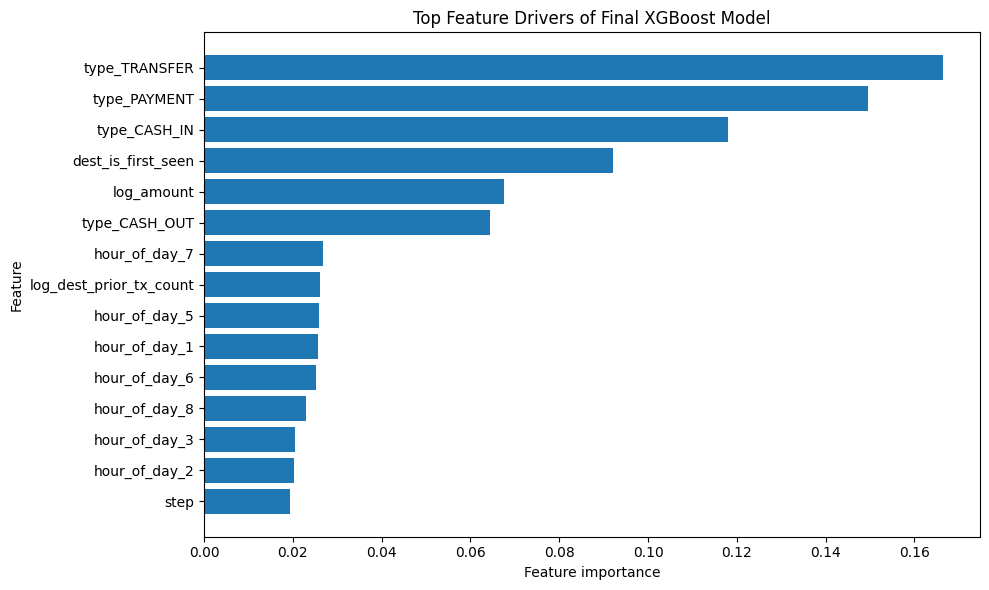

In [58]:
xgb_feature_importance = pd.DataFrame({
    'feature': X_trainvalid_xgb.columns,
    'importance': final_xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(xgb_feature_importance.head(15))

top_n = 15
top_imp = xgb_feature_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title('Top Feature Drivers of Final XGBoost Model')
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The final XGBoost model is driven primarily by transaction type, novelty of the destination entity, transaction size, and intraday timing, with additional contribution from destination-side historical activity and broader temporal position.

### 3.8 SHAP-based interpretation of the final XGBoost model

Tree-based feature importance provides a useful high-level ranking, but SHAP offers a more informative explanation of how features influence model predictions.

In this section, SHAP is used to:
- summarize the global importance of features,
- show how feature values push predictions higher or lower,
- and inspect individual high-risk examples.

To keep runtime manageable, SHAP is computed on a sample of the holdout set.

In [74]:
try:
    import shap
except ImportError:
    raise ImportError(
        "The shap package is not installed. Install it with `pip install shap` "
        "or `conda install -c conda-forge shap`."
    )

SHAP_SAMPLE_SIZE = min(2000, len(X_holdout_xgb))

X_shap = X_holdout_xgb.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=SEED
).copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 37)


In [75]:
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer(X_shap)

print("SHAP values computed.")

SHAP values computed.


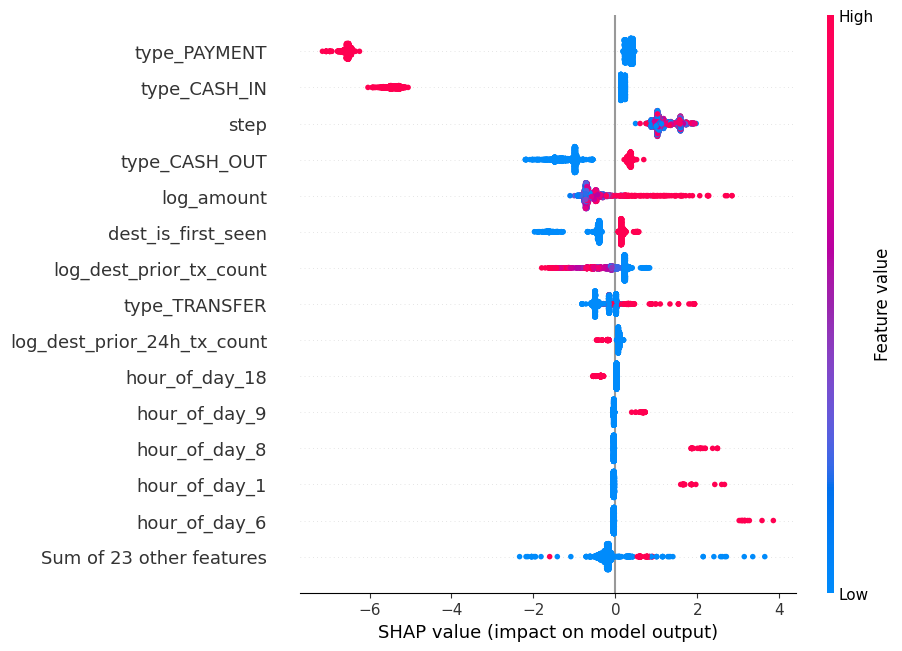

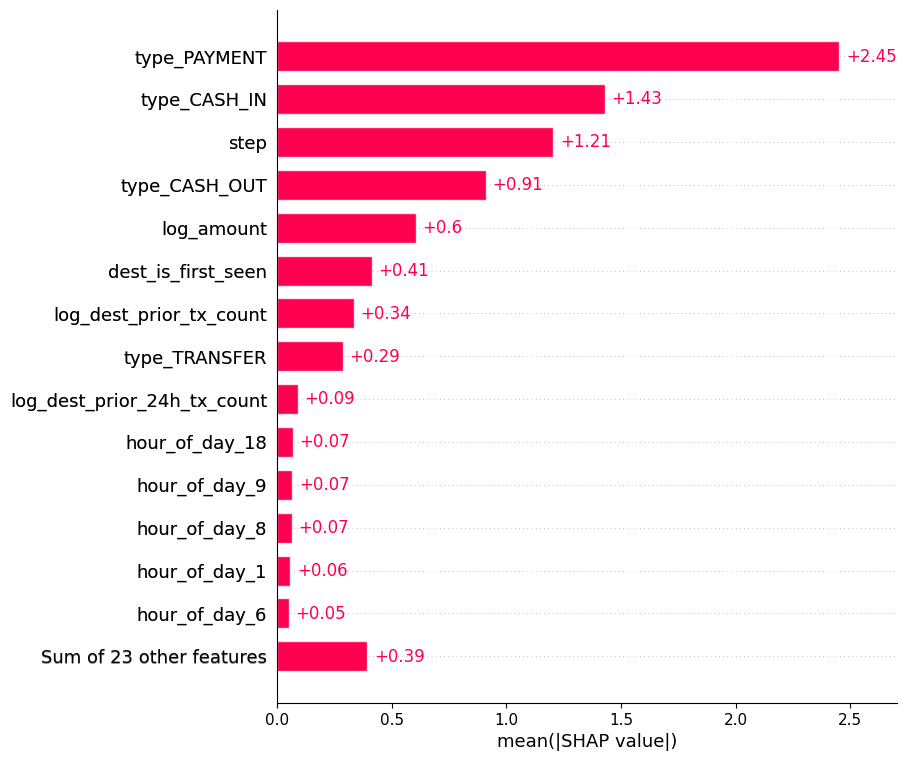

In [76]:
# Beeswarm summary plot
shap.plots.beeswarm(shap_values, max_display=15)

# Bar plot of mean absolute SHAP importance
shap.plots.bar(shap_values, max_display=15)

The SHAP results show that the final XGBoost model is driven primarily by transaction type, transaction size, destination novelty, destination-side historical activity, and temporal structure.

The direction of these effects is also informative. `type_PAYMENT` and `type_CASH_IN` act as strong negative risk signals, pushing predictions lower when present. In contrast, `type_TRANSFER` and `type_CASH_OUT` push predictions higher. Larger transaction amounts also increase risk, while higher destination-side historical activity tends to reduce risk. In addition, first-seen destination accounts and certain hours of day contribute positively to model risk.

Overall, the SHAP analysis confirms that the model is combining transaction-category information, behavioral novelty, account-history features, and temporal patterns rather than relying on any single variable alone.

#### Explain one high-risk example

Top-risk transaction index: 1568
Predicted probability: 0.99993217
True label: 1


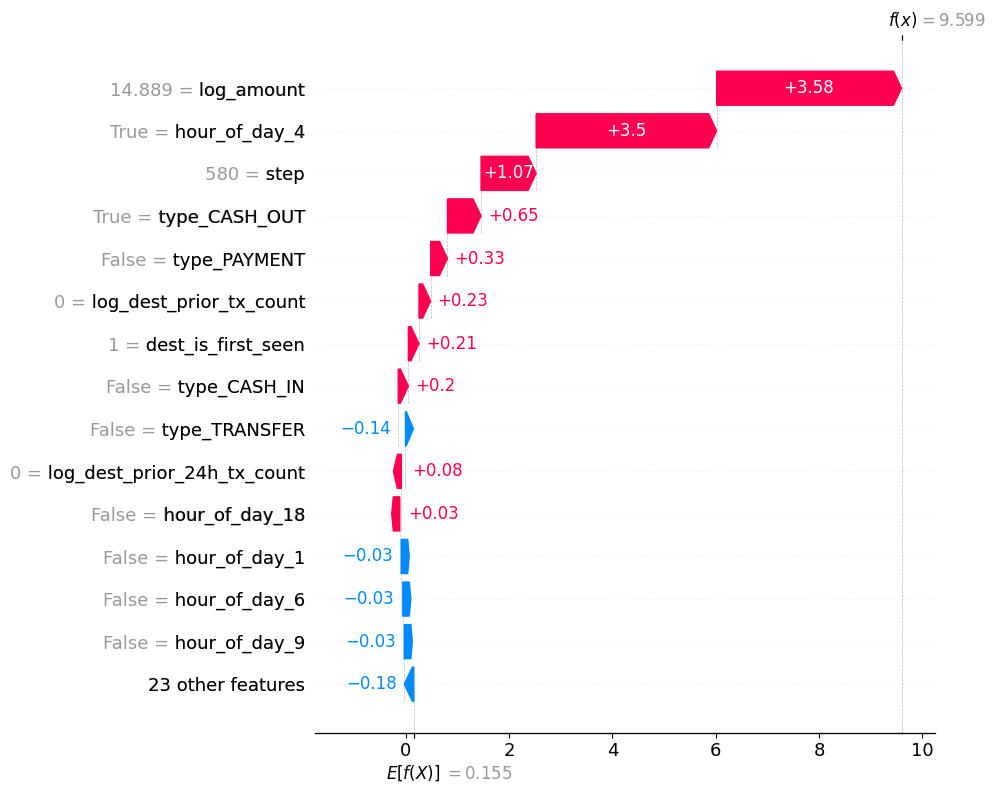

In [62]:
# Pick one high-risk holdout example
top_idx = np.argmax(holdout_scores_xgb)

# Align with SHAP source matrix
single_row = X_holdout_xgb.iloc[[top_idx]].copy()
single_explanation = explainer(single_row)

print("Top-risk transaction index:", top_idx)
print("Predicted probability:", holdout_scores_xgb[top_idx])
print("True label:", y_holdout_xgb.iloc[top_idx])

shap.plots.waterfall(single_explanation[0], max_display=15)

The SHAP waterfall plot for a top-risk transaction shows that the final XGBoost model assigns a very high score because several strong risk signals appear together. The largest positive drivers are transaction size, a high-risk hour-of-day pattern, later timeline position, and the `CASH_OUT` transaction type. Additional positive contributions come from destination-side novelty and limited destination-side historical activity. At the same time, the transaction is not a `PAYMENT` or `CASH_IN`, so it does not benefit from those strong low-risk signals. Overall, this is a clear example of multiple risk factors stacking in the same transaction, which pushes the model output to an extremely high level.

### 3.9 High-risk transaction review

Aggregate metrics show how the final XGBoost model performs overall, but they do not show what the model is actually prioritizing.

This section reviews the highest-scored holdout transactions to answer two questions:

- what patterns appear in the top-risk alerts,
- and whether the highest-risk cases are consistent with the earlier feature-importance and SHAP interpretation.

#### Top-risk holdout examples

In [63]:
holdout_review_df = holdout_df.copy().reset_index(drop=True)

holdout_review_df['score_xgb'] = holdout_scores_xgb
holdout_review_df['pred_alert_xgb'] = holdout_preds_xgb

review_columns = [
    'transaction_id',
    'step',
    'type',
    'amount',
    'log_amount',
    'hour_of_day',
    'orig_is_first_seen',
    'dest_is_first_seen',
    'log_orig_prior_tx_count',
    'log_dest_prior_tx_count',
    'log_orig_prior_24h_tx_count',
    'log_dest_prior_24h_tx_count',
    TARGET,
    'score_xgb',
    'pred_alert_xgb'
]

top_risk_examples = (
    holdout_review_df[review_columns]
    .sort_values('score_xgb', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_risk_examples)

top_risk_summary = pd.DataFrame([
    {'metric': 'Top 20 examples reviewed', 'value': len(top_risk_examples)},
    {'metric': 'Frauds in top 20', 'value': int(top_risk_examples[TARGET].sum())},
    {'metric': 'Precision in top 20', 'value': top_risk_examples[TARGET].mean()},
    {'metric': 'Mean score in top 20', 'value': top_risk_examples['score_xgb'].mean()},
    {'metric': 'Median amount in top 20', 'value': top_risk_examples['amount'].median()}
])

display(top_risk_summary)

,transaction_id,step,type,amount,log_amount,hour_of_day,orig_is_first_seen,dest_is_first_seen,log_orig_prior_tx_count,log_dest_prior_tx_count,log_orig_prior_24h_tx_count,log_dest_prior_24h_tx_count,isFraud,score_xgb,pred_alert_xgb
0,6201885,580,CASH_OUT,"2,925,111.670000",14.888844,4,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999932,1
1,6351204,701,CASH_OUT,"8,537,861.240000",15.960021,5,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999924,1
2,6272973,629,CASH_OUT,"8,488,865.830000",15.954266,5,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999924,1
3,6296671,677,CASH_OUT,"9,295,454.240000",16.045036,5,1,0,0.000000,2.079442,0.000000,0.000000,1,0.999918,1
4,6201754,578,CASH_OUT,"6,274,752.670000",15.652045,2,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999918,1
5,6296625,674,CASH_OUT,"6,250,438.780000",15.648162,2,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999918,1
6,6351136,698,CASH_OUT,"9,097,679.750000",16.023530,2,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999918,1
7,6351222,702,CASH_OUT,"10,000,000.000000",16.118096,6,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999914,1
8,6296665,676,CASH_OUT,"3,542,716.020000",15.080405,4,1,0,0.000000,1.098612,0.000000,0.000000,1,0.999910,1
9,6281810,652,CASH_OUT,"2,054,631.550000",14.535608,4,1,1,0.000000,0.000000,0.000000,0.000000,1,0.999903,1


,metric,value
0,Top 20 examples reviewed,20.000000
1,Frauds in top 20,20.000000
2,Precision in top 20,1.000000
3,Mean score in top 20,0.999906
4,Median amount in top 20,"6,262,595.725000"


### Interpretation of the top-risk holdout examples

The highest-scored holdout transactions are highly concentrated in a very consistent risk pattern. All top 20 reviewed examples are true fraud cases, giving a precision of 1.00 in the top-risk slice. This indicates that the final XGBoost model is ranking the most suspicious transactions very effectively.

These top-risk examples are dominated by large `CASH_OUT` transactions, often in the multi-million range, and many occur during a narrow set of higher-risk hours. In addition, sender-side and destination-side history features are typically sparse, with frequent first-seen indicators and low prior activity. This pattern is consistent with the earlier SHAP analysis: the model is prioritizing transactions that combine high-risk transaction type, large amount, temporal risk, and novelty / limited historical support.

Overall, the top-risk review suggests that the final model is not only strong in aggregate metrics, but also highly effective at surfacing a coherent set of high-risk transactions at the very top of the ranking.

#### Segment performance analysis

In [64]:
segment_df = holdout_df.copy().reset_index(drop=True)
segment_df['score_xgb'] = holdout_scores_xgb
segment_df['pred_alert_xgb'] = holdout_preds_xgb

# Segment 1: transaction type
type_segment_summary = (
    segment_df.groupby('type')
    .apply(lambda g: pd.Series({
        'rows': len(g),
        'fraud_count': int(g[TARGET].sum()),
        'fraud_rate': g[TARGET].mean(),
        'precision': precision_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'recall': recall_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'f1': f1_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'alert_rate': g['pred_alert_xgb'].mean()
    }))
    .reset_index()
)

# Segment 2: destination novelty
dest_novelty_summary = (
    segment_df.groupby('dest_is_first_seen')
    .apply(lambda g: pd.Series({
        'rows': len(g),
        'fraud_count': int(g[TARGET].sum()),
        'fraud_rate': g[TARGET].mean(),
        'precision': precision_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'recall': recall_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'f1': f1_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'alert_rate': g['pred_alert_xgb'].mean()
    }))
    .reset_index()
    .rename(columns={'dest_is_first_seen': 'dest_is_first_seen_segment'})
)

# Segment 3: amount bands
segment_df['amount_band'] = pd.qcut(segment_df['amount'], q=4, duplicates='drop')

amount_segment_summary = (
    segment_df.groupby('amount_band')
    .apply(lambda g: pd.Series({
        'rows': len(g),
        'fraud_count': int(g[TARGET].sum()),
        'fraud_rate': g[TARGET].mean(),
        'precision': precision_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'recall': recall_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'f1': f1_score(g[TARGET], g['pred_alert_xgb'], zero_division=0),
        'alert_rate': g['pred_alert_xgb'].mean()
    }))
    .reset_index()
)

display(type_segment_summary)
display(dest_novelty_summary)
display(amount_segment_summary)

,type,rows,fraud_count,fraud_rate,precision,recall,f1,alert_rate
0,CASH_IN,"37,321.000000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,CASH_OUT,"52,566.000000",927.000000,0.017635,0.187746,0.667745,0.293087,0.062721
2,DEBIT,"1,328.000000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,PAYMENT,"55,537.000000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,TRANSFER,"15,551.000000",927.000000,0.059610,0.352204,1.000000,0.520933,0.169250


,dest_is_first_seen_segment,rows,fraud_count,fraud_rate,precision,recall,f1,alert_rate
0,0,"90,148.000000",679.000000,0.007532,0.201311,0.633284,0.305506,0.023694
1,1,"72,155.000000","1,175.000000",0.016284,0.294226,0.949787,0.449275,0.052567


,amount_band,rows,fraud_count,fraud_rate,precision,recall,f1,alert_rate
0,"(-0.001, 11598.19]","40,576.000000",55.000000,0.001355,0.161157,0.709091,0.262626,0.005964
1,"(11598.19, 70834.66]","40,576.000000",242.000000,0.005964,0.193168,0.677686,0.300642,0.020924
2,"(70834.66, 202362.56]","40,575.000000",306.000000,0.007542,0.164280,0.712418,0.266993,0.032705
3,"(202362.56, 15415938.31]","40,576.000000","1,251.000000",0.030831,0.320422,0.899281,0.472491,0.086529


### Interpretation of segment performance

The segment analysis shows that model performance is not uniform across the holdout population.

By transaction type, fraud remains concentrated in `TRANSFER` and `CASH_OUT`, and the model performs strongest on these groups. In particular, recall is highest for `TRANSFER`, while `CASH_OUT` remains more challenging because it contains a larger volume of legitimate transactions that still resemble suspicious activity.

By destination novelty, the model performs substantially better when `dest_is_first_seen = 1`. This group has a higher underlying fraud rate, and the model achieves both higher precision and much higher recall, which is consistent with the earlier novelty-based feature interpretation.

By transaction amount, performance improves in the highest amount band. The highest-value transactions have the highest fraud rate, and the model responds by producing both higher alert rates and stronger precision / recall. This supports the earlier conclusion that transaction size is an important risk signal, especially when combined with type and novelty features.

Overall, the segment results show that the final model is strongest in the groups that are also most operationally relevant: high-risk transaction types, first-seen destination entities, and high-value transactions.

#### Export scored holdout CSV

In [66]:
scored_holdout_df = holdout_df.copy().reset_index(drop=True)[['transaction_id', TARGET]].rename(
    columns={TARGET: 'label'}
)

scored_holdout_df['score'] = holdout_scores_xgb
scored_holdout_df['threshold_alert'] = holdout_preds_xgb.astype(int)

output_path = 'paysim_holdout_scored.csv'
scored_holdout_df.to_csv(output_path, index=False)

display(scored_holdout_df.head())
print(f"Scored holdout file saved to: {output_path}")

,transaction_id,label,score,threshold_alert
0,6200317,0,0.001500,0
1,6200318,0,0.001376,0
2,6200319,0,0.001376,0
3,6200320,0,0.001500,0
4,6200321,0,0.001883,0


Scored holdout file saved to: paysim_holdout_scored.csv


## 3.10 Final conclusions

This case study built a transaction-level suspicious-activity scoring workflow under severe class imbalance and time-ordering constraints.

The main conclusions are:

- A simple logistic-regression baseline already captured meaningful signal from transaction type, amount, and timeline position.
- Adding temporal and behavioral-history features materially improved the benchmark.
- XGBoost provided additional lift by capturing non-linear interactions among transaction type, timing, novelty, and destination-side history.
- Validation-based threshold selection was necessary to translate ranking performance into an operational alerting decision.
- SHAP analysis showed that the final model is driven primarily by transaction type, transaction amount, destination novelty, destination-side historical activity, and temporal structure.
- High-risk example review and segment analysis showed that the final model’s behavior is consistent with the earlier exploratory findings.

Overall, the final workflow combines leakage-aware feature engineering, time-based validation, interpretable benchmarking, stability-aware advanced-model tuning, and business-oriented threshold selection.

## 3.11 Future steps

If more time and compute resources were available, the next extensions would focus on four areas.

### 1. Richer behavioral feature engineering
The current model already uses transaction type, amount, novelty, and prior-count features, but the feature space could be expanded further. The most valuable next additions would likely include:

- rolling amount features over multiple windows (for example, 1-hour, 24-hour, and 7-day windows),
- ratio features comparing recent activity to longer-run historical activity,
- sender-side and receiver-side amount concentration measures,
- and interaction-style behavioral features that better capture unusual transaction context.

These additions could improve detection of more subtle suspicious patterns beyond the strongest fraud signatures already captured.

### 2. Broader advanced-model search
The XGBoost tuning process in this notebook was intentionally narrowed to remain practical on local compute. With more compute power, the advanced-model stage could be extended through:

- a larger random-search budget,
- a broader narrowed-grid search,
- more rolling time-based folds,
- and potentially deeper comparison across alternative tree-based models.

This would provide a more exhaustive search of the non-linear modeling space and reduce the chance that a stronger configuration was missed due to runtime constraints.

### 3. Stronger threshold and stability analysis
The final threshold was selected on validation using expected cost and operational burden metrics. With more time, this could be extended by:

- checking threshold stability across multiple validation windows,
- comparing alert-volume stability across time periods,
- and stress-testing the final threshold under alternative cost assumptions.

This would make the operational recommendations more robust and less dependent on a single validation period.

### 4. Expanded interpretation and case review
The current notebook includes SHAP analysis, top-risk example review, and segment-level performance analysis. Additional interpretability work could include:

- more local SHAP explanations across different fraud patterns,
- more systematic review of false positives and false negatives,
- and targeted analysis of model behavior across specific operational slices.

This would help identify where the model is strongest, where it still fails, and which types of suspicious activity remain hardest to distinguish.

### Overall next step
The strongest next version of this case study would combine a richer behavioral feature set, a larger advanced-model search, and more robust threshold-stability analysis. The current notebook shows that the modeling workflow is effective, and the next iteration would mainly aim to improve coverage, robustness, and operational confidence rather than change the overall modeling direction.

### Limitation note on `step`

The variable `step` was retained in this case study as a coarse temporal-position feature, and under the time-based split it provided useful signal. However, its interpretation should be cautious.

Because transaction volume changes materially across the simulation timeline, part of the predictive value of `step` may reflect dataset-specific temporal structure rather than a stable business mechanism. In particular, an absolute timeline index can become a shortcut feature if later portions of the dataset differ systematically from earlier portions.

This concern is especially important for real production settings. Unlike more interpretable time-derived features such as hour of day, day of week, recency, or rolling-window activity, an absolute timeline index does not naturally generalize as time extends beyond the training range. In a production workflow, this feature would therefore be treated cautiously, stress-tested through ablation analysis, and potentially replaced by more stable time-derived features.